<a href="https://colab.research.google.com/github/borjabmadurga2-creator/Data-Analytics---Borja/blob/main/Sprint9_Borja_Belmonte/sprint9_Borja_Belmonte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este Sprint, trabajaremos la interpretación analítica y el storytelling basado en datos con los que hemos trabajado anteriormente en BigQuery.

Aprenderemos a construir visualizaciones en Python como alternativa a herramientas BI.

El objetivo es aprender a crear gráficos en Python, analizarlos, y responder preguntas de negocio.

**Nivel 1 - Visualización analítica guiada en Python**

El objetivo es aplicar lógica analítica para responder preguntas de negocio mediante visualizaciones en Python. Se pide:

- Identificar qué información es necesaria
- Escoger correctamente la tabla o tablas relevantes
- Construir visualizaciones adecuadas
- Interpretar los resultados obtenidos

Conexión a MySql y la base de datos que contiene las tablas que vamos a usar a lo largo de todo el Sprint

In [1]:
#comprobación de que la conexión se ha hecho correctamente
import os
import socket
import sys

print("Equipo:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equipo: DESKTOP-JTDFU4N
Python: C:\Users\Usuario\AppData\Local\Programs\Python\Python313\python.exe
Usuari: Usuario


In [2]:
#instalación librerías necesarias para la conexión con mysql
%pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
from sqlalchemy import create_engine#creación motor para conexión mysql
from getpass import getpass#para pedir datos sensibles, sin que aparezca en pantalla, como p.ej. contraseñas
import pandas as pd
#genero la conexión a la bbdd
usuario = "root"
password = getpass("Contraseña MySql: ")#pido la contraseña por consola para que no aparezca por pantalla
host= "localhost"
puerto = 3306
bbdd = "ejercicios_csv"
#uso los datos para el motor de la conexión
engine = create_engine(f"mysql+pymysql://{usuario}:{password}@{host}:{puerto}/{bbdd}")
with engine.connect() as conn:
  print("Conexión exitosa!")

Contraseña MySql: ··········
Conexión exitosa!


Preguntas analíticas usando solo la tabla "Transaction":
¿Cómo evoluciona el número de transacciones a lo largo del tiempo? Ejemplo de pasos a seguir:

- Selecciona la columna temporal adecuada
- Define el nivel temporal de análisis
- Cuenta el número de registros de cada periodo temporal
- Ordena los resultados de manera cronológica
- Visualiza la evolución con un gráfico de líneas de Pandas

In [4]:
#conectamos a la tabla transactions como pide el ejercicio y la mostramos como datafram
tabla = "transaction"
df=pd.read_sql(tabla, engine)
df.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


In [5]:
#comprobaciones del dataframe
df.shape#nº de filas y columnas del dataframe

(99999, 19)

In [6]:
df.dtypes#revision del tipo de datos que contiene el datafram

id                             str
card_id                        str
business_id                    str
timestamp           datetime64[us]
amount                     float64
declined                     int64
product_ids                    str
user_id                      int64
lat                        float64
longitude                  float64
discount_amount            float64
tax_amount                 float64
shipping_amount            float64
channel                        str
campaign_id                    str
device_type                    str
is_international             int64
decline_reason                 str
distance_km                float64
dtype: object

In [7]:
df.isnull().sum()#revisión de valores nulos

id                  0
card_id             0
business_id         0
timestamp           0
amount              0
declined            0
product_ids         0
user_id             0
lat                 0
longitude           0
discount_amount     0
tax_amount          0
shipping_amount     0
channel             0
campaign_id         0
device_type         0
is_international    0
decline_reason      0
distance_km         0
dtype: int64

Selección de la columna temporal



In [8]:
#reviso las fechas máxima y mínima del dataset, para ver cuántos registros dispone. el dataset va de 2015 a 2024
print(df['timestamp'].min())
print(df['timestamp'].max())

2015-01-01 00:40:23
2024-12-31 23:31:55


In [9]:
#creo una columna mes para seleccionar por periodo mensual
df["mes"] = df["timestamp"].dt.to_period("M")

#cuento las transacciones por registro temporal (mes)
transacciones_mes = df.groupby("mes").size()
transacciones_mes

mes
2015-01    818
2015-02    816
2015-03    835
2015-04    829
2015-05    812
          ... 
2024-08    824
2024-09    827
2024-10    823
2024-11    816
2024-12    871
Freq: M, Length: 120, dtype: int64

Gráfico de barras con Pandas

<Axes: title={'center': 'Evolución de transacciones mensuales'}, xlabel='mes'>

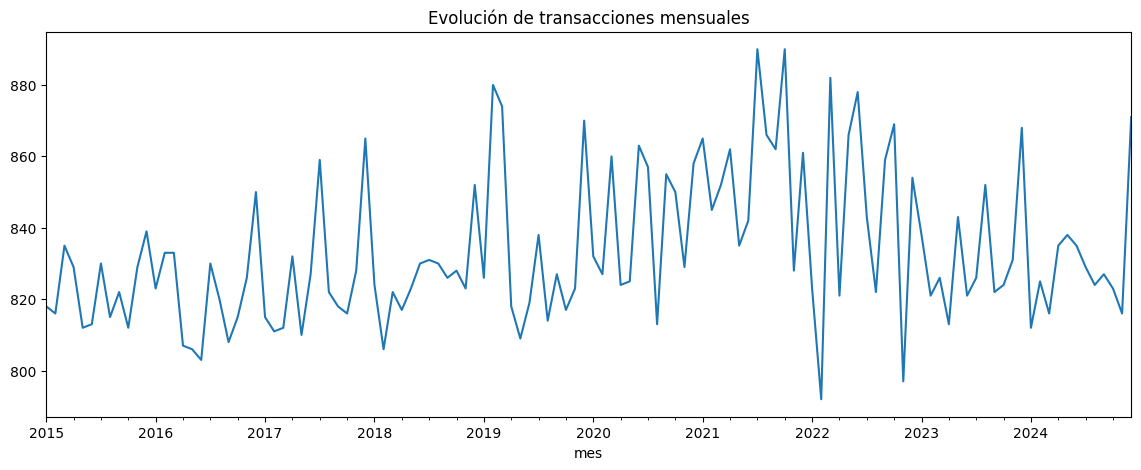

In [10]:
#creo el gráfico de líneas con pandas
transacciones_mes.plot(kind="line", figsize=(14,5), title="Evolución de transacciones mensuales")

En este primer gráfico de la evolución de transacciones mensuales, podemos ver:

**Tendencia geneal:** el volumen de transacciones se mantiene bastante estable, entre las 790 y las 880 transacciones al mes. No hay una tendencia sostenida de crecimiento o caída.

**Variabilidad:** la oscilación mensual es bastante ruidosa (sube y baja constantemente), aunque no se aprecia un patrón constante estacional (no hay picos repetidos en un mismo mes y/o periodo)

**Años clave:** entre 2021 y 2022 es cuando más se aprecia la volatilidad de las transacciones. Los picos máximos (880) se encuentran en el periodo de 2021 y no descienden de 830, sin embargo, en 2022 se mantiene estable mostrando los picos más bajos, alcanzando las 790 transacciones. La variabilidad es mínima antes de 2021.

**Conclusión:** el negocio parece tener un volumen de transacciones consistente, sin crecimiento ni caídda significante.

¿Qué usuarios generan más volumen de facturación? Ejemplo de pasos guiados con Seaborn:

- Identifica la columna que representa el usuario
- Agrupa las transacciones por usuario y calcula el volumen total de facturación sumando la columna amount
- Ordena los usuarios de mayor a menor volumen de facturación
- Selecciona los N usuarios principales (por ejemplo los 15 primeros)

Representa el resultado mediante un gráfico de barras usando Seaborn


In [11]:
#en primer lugar, importo la librería seaborn y la libreria matplotlib
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
#en este dataset, el identificador de usuario es la columna user_id
facturación_usuario = df.groupby("user_id")["amount"].sum()#agrupo por user_id y selecciono el sumatorio del amount. hay 5000 usuarios únicos, como muestra el resultado
facturación_usuario = facturación_usuario.sort_values(ascending=False)#ordeno los valores de mayor a menor

facturación_usuario

user_id
289     47332.90
318     47133.55
455     41396.68
417     37393.91
185     34576.49
          ...   
3652     1432.29
1306     1421.15
1995     1405.70
3119     1327.53
621      1237.00
Name: amount, Length: 5000, dtype: float64

In [13]:
#selecciono los 15 primeros usuarios
top_usuarios = facturación_usuario.head(15)
top_usuarios

user_id
289    47332.90
318    47133.55
455    41396.68
417    37393.91
185    34576.49
285    33383.56
454    29528.42
349    27835.38
193    27462.59
317    22484.76
388    21313.31
443    20605.24
319    20455.52
393    19632.36
437    18518.81
Name: amount, dtype: float64

In [14]:
#para que seaborn pueda interpretarlo mejor, paso la serie anterior (top_usuarios) a dataframe, creando dos columnas, user_id y amount
top_usuarios_df = top_usuarios.reset_index()#con reset_index() convierto la serie a dataframe y hereda directamente el nombre de las columnas
#top_usuarios_df.columns = ["user_id","amount"] con este comando crearíamos las columnas, pero en este caso es un paso redundante, ya que las hereda directamente, no es necesario especificar

top_usuarios_df


,user_id,amount
0,289,47332.90
1,318,47133.55
2,455,41396.68
3,417,37393.91
4,185,34576.49
5,285,33383.56
6,454,29528.42
7,349,27835.38
8,193,27462.59
9,317,22484.76


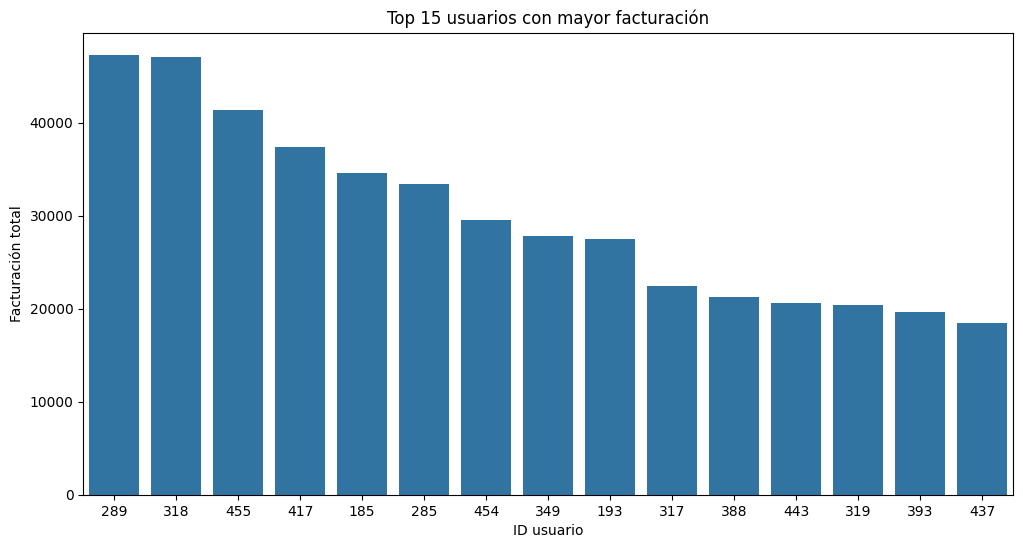

In [15]:

#muestro el gráfico de barras del dataframe top_usuarios_fd
plt.figure(figsize=(12,6))#tamaño del gráfico
sns.barplot(data=top_usuarios_df, x="user_id", y="amount", order=top_usuarios_df["user_id"])#indico los datos del df, las referencias del gráfico x,y y el orden
plt.title("Top 15 usuarios con mayor facturación")
plt.xlabel("ID usuario")
plt.ylabel("Facturación total")
plt.show()


Los usuarios 289 y 318 están casi empatados en facturación. A partir de ahí, el descenso es progresivo, sin picos bruscos, siendo el total facturado bastante similar entre los usuarios a medida que baja. El negocio no depende de un solo usuario, por lo que, si el usuario 289 fallase, no sería un golpe catastrófico para el negocio.

A pesar de ello, estos 15 usuarios que son los que más facturan, son candidatos a tenerlos en cuenta para programas VIP y/o fidelización (como descuentos exclusivos, promociones...). También puede haber un contacto directo con los usuarios para entender su comportamiento y tratar de replicarlo en otros usuarios con menor volumen de facturación. Por último, también sería importante crear alertas en caso de que el volumen de facturación de estos 15 usuarios descienda.



In [16]:
#cálculo del porcentaje total que representan estos 15 clientes
facturacion_total = df["amount"].sum()#aquí cojo el volumen de gasto total de todos los usuarios
facturacion_top15 = top_usuarios_df["amount"].sum()#aquí cojo el volumen del gasto total del top 15
porcentaje = (facturacion_top15 / facturacion_total) * 100
print(f"El top 15 de usuarios facturan el {porcentaje:.2f}% de la facturación total")


El top 15 de usuarios facturan el 1.53% de la facturación total


Con este cálculo, vemos que el top 15 usuarios suponen el 1,53% de las ventas, de un total de 5000 usuarios únicos. Por tanto, el 0,3% de los clientes, generan un 1,53% del total de ventas (casi 5 veces más si no estuviera repartido).

Esto muestra que las ventas de negocio están muy democratizadas, implicando que las ventas se reparten entre los usuarios.
Este resultado muestra que este negocio no cumple con el principio de Pareto, en el que el 80% de las compras, las realizan el 20% de usuarios.

Hay diferencia en la distribución del importe de las transacciones según la hora del día y si han sido aceptadas o rechazadas? Ejemplo de pasos guiados con Seaborn:

- Crea una nueva columna con la hora del día a partir del timestamp
- Usa un violinplot de seaborn para analizar la distribución de los importes
- Asigna: x para la hora del día, y para el importe de la transacción y hue para el estado de la transacción
- Activa split para comparar aceptadas y rechazadas y inner con quartile para mostrar la mediana y cuartiles


In [17]:
#creo la columna "hora" con la hora del dia de la columna timestamp
df["hora"] = (df["timestamp"]).dt.hour#extraigo solo la hora de la columna timestamp
df["hora"].head()#muestro resultado

0     7
1    15
2    19
3    18
4     4
Name: hora, dtype: int32

In [18]:
#de la columna declined, paso los datos booleanos a string
df["estado_transaccion"] = df["declined"].map({0: "Aceptada", 1: "Rechazada"})#mapeo para que 0 sea aceptada y 1 rechazada
df["estado_transaccion"].head()#muestro como queda

0    Aceptada
1    Aceptada
2    Aceptada
3    Aceptada
4    Aceptada
Name: estado_transaccion, dtype: str

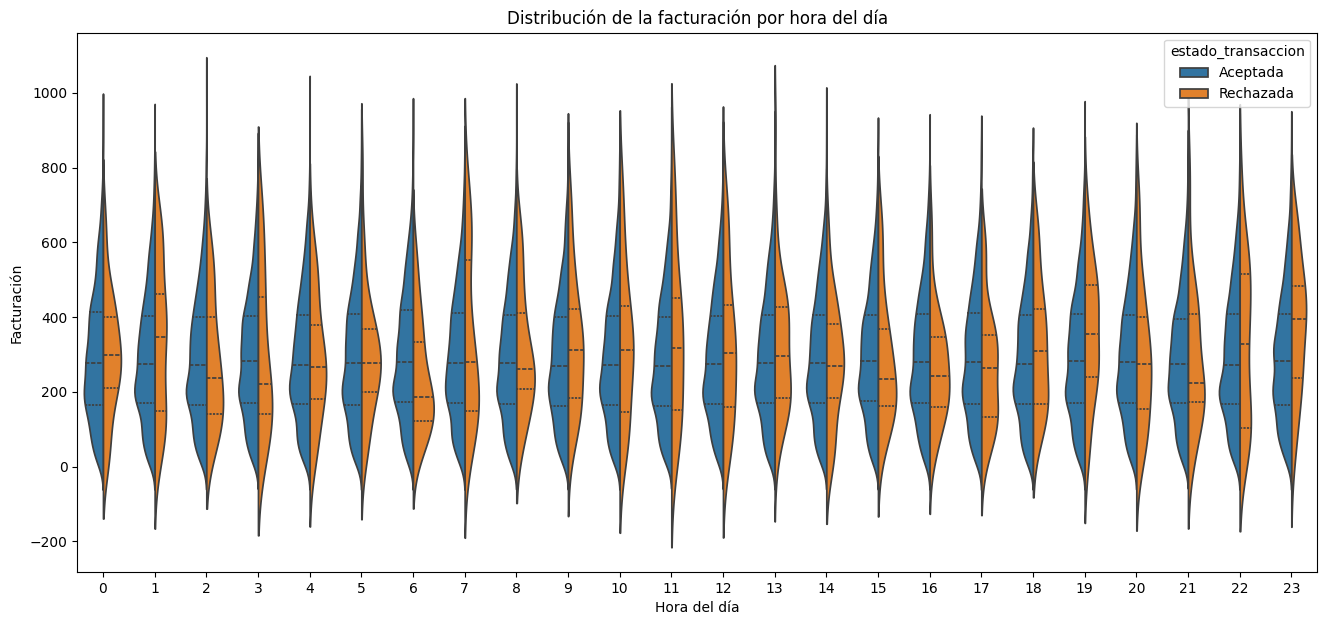

In [19]:
#creación del gráfico violinplot
plt.figure(figsize=(16,7))#tamaño del gráfico
sns.violinplot(data=df, x="hora", y="amount", hue="estado_transaccion", split=True, inner="quartile")#indico de donde quiero que saque los datos (df), marco los ejes x,y. hue añade una segunda separación de los datos, en este caso por "estado_transaccion", split=true muestra en un mismo violín 2 datos
plt.title("Distribución de la facturación por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Facturación")
plt.show()

**Patrón horario**:La distribución de importes es similar hora tras hora, no hay una franja horaria en la que el negocio venda especialmente distinta (ni en volumen ni en importe). La actividad parece homogenea a lo largo del día.

**Aceptadas vs. Rechazadas:** En la práctica totalidad de las horas, las transacciones rechazadas tiene su mediana y cuartiles ligeramente por encima de las transacciones aceptadas. Esto sugiere que las transacciones con importes más altos tienen algo más de probabilidad de ser rechazadas.

A pesar de tener cierto sentido con un patrón antifraude, que rechaza las transacciones con más volumen de gasto, podría ser interesante para el negocio revisar si el sistema se encuentra bien calibrado para hacer la transacción de estas compras más caras.

In [20]:
#revisión de la media entre las transacciones aceptadas y rechazadas
df.groupby("estado_transaccion")["amount"].median()#agrupo por la columna creada estado_transaccion, selecciono la columna amount y hago la mediana

estado_transaccion
Aceptada     275.880
Rechazada    287.215
Name: amount, dtype: float64

Como se puede observar, hay una pequeña diferencia entre las transacciones aceptadas y rechazadas, a pesar de ello, los datos muestran que existe un patrón, pero que no supone una gran diferencia.

¿Qué días de la semana se concentra más actividad de venta?

Primero calculo las transacciones totales por día de la semana

In [21]:
#extraigo el nombre del día de la semana y lo guardo en una nueva columna dia_semana
df["dia_semana"] = df["timestamp"].dt.day_name()
df["dia_semana"].head()

0    Wednesday
1      Tuesday
2       Monday
3     Thursday
4     Saturday
Name: dia_semana, dtype: str

In [22]:
#reviso el nº de filas (transacciones) por día de la semana
transacciones_dia = df.groupby("dia_semana").size()
transacciones_dia
#el resultado muestra los días de la semana por orden alfabético

dia_semana
Friday       14272
Monday       14122
Saturday     14353
Sunday       14289
Thursday     14516
Tuesday      14176
Wednesday    14271
dtype: int64

In [23]:
#cambio los días de la semana de orden alfabético a orden de día
dia_ordenado = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]#creo una lista con los nombres ordenados
transacciones_dia = transacciones_dia.reindex(dia_ordenado)#reordeno la serie en base a la lista creada y ordenada
transacciones_dia

dia_semana
Monday       14122
Tuesday      14176
Wednesday    14271
Thursday     14516
Friday       14272
Saturday     14353
Sunday       14289
dtype: int64

In [24]:
#conversión a dataframe para que seaborn pueda interpretar los datos correctamente
transacciones_dia_df = transacciones_dia.reset_index()
transacciones_dia_df.columns = ["dia_semana", "num_transacciones"]
transacciones_dia_df

,dia_semana,num_transacciones
0,Monday,14122
1,Tuesday,14176
2,Wednesday,14271
3,Thursday,14516
4,Friday,14272
5,Saturday,14353
6,Sunday,14289


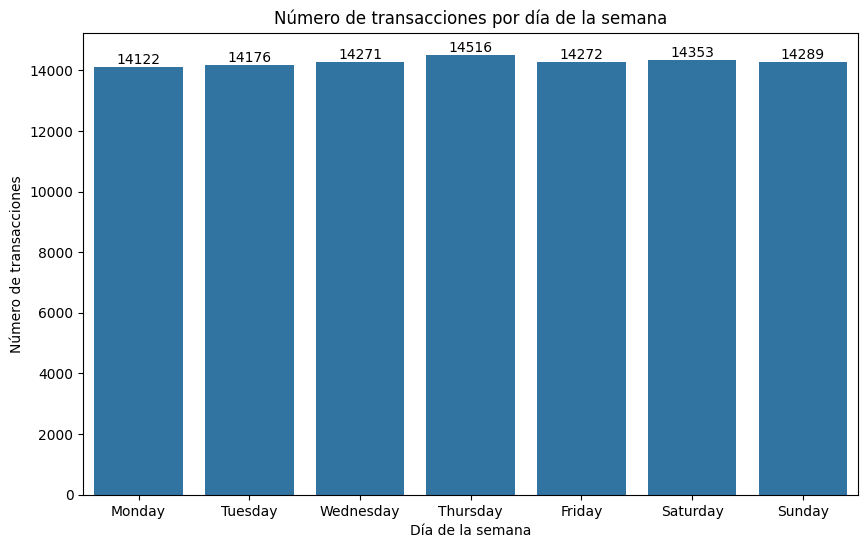

In [25]:
#creo un gráfico de barras para mostrar las ventas por dia de la semana
plt.figure(figsize=(10,6))
ax = sns.barplot(data=transacciones_dia_df, x="dia_semana", y="num_transacciones", order=dia_ordenado)#lo guardo en la variable ax para poder llamarla después en el gráfico y añadir los datos
#añado etiquetas sobre las barras
for contenedor in ax.containers:#grupos de barras
    ax.bar_label(contenedor, fmt='%.0f')#añade los nº sobre el gráfico
plt.title("Número de transacciones por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de transacciones")
plt.show()

Se puede apreciar que no hay una gran diferencia entre ventas por día de la semana. El máximo de ventas se da el Jueves con 14516 transacciones, y el mínimo el lunes, con 14122. Supone una diferencia de 394 transacciones entre ambos días.

In [26]:
#calculo el procentaje de diferencia entre ambos datos
diferencia = (14516 - 14122) / 14122 * 100
print(f"La diferencia entre las ventas del lunes y el jueves es del {diferencia:.2f}%")

La diferencia entre las ventas del lunes y el jueves es del 2.79%


Una vez calculada la diferencia porcentual entre las ventas del lunes y el jueves (la más alta y la más baja), se aprecia que la diferencia es de un 2,79%, indicando que no hay grandes cambios en cuanto a ventas a lo largo de la semana.

Ahora calculo el total de ventas por día

In [27]:
#una vez calculado el total de ventas por día, vamos a calcular el total deingresos por día (volumen de dinero por día). también vamos a ordenar los días de la semana con reindex y la lista creada antes
facturacion_dia = df.groupby("dia_semana")["amount"].sum()#agrupo por dia de la semana y el sumatorio del amount
facturacion_dia = facturacion_dia.reindex(dia_ordenado)#ordeno los días de la semana
facturacion_dia


dia_semana
Monday       4096187.82
Tuesday      4182931.19
Wednesday    4169193.18
Thursday     4228670.00
Friday       4206553.59
Saturday     4221384.93
Sunday       4190381.08
Name: amount, dtype: float64

In [28]:
#transformo la serie en una dataframe
facturacion_dia_df = facturacion_dia.reset_index()
facturacion_dia_df.columns = ["dia_semana", "facturacion_total"]
facturacion_dia_df

,dia_semana,facturacion_total
0,Monday,4096187.82
1,Tuesday,4182931.19
2,Wednesday,4169193.18
3,Thursday,4228670.00
4,Friday,4206553.59
5,Saturday,4221384.93
6,Sunday,4190381.08


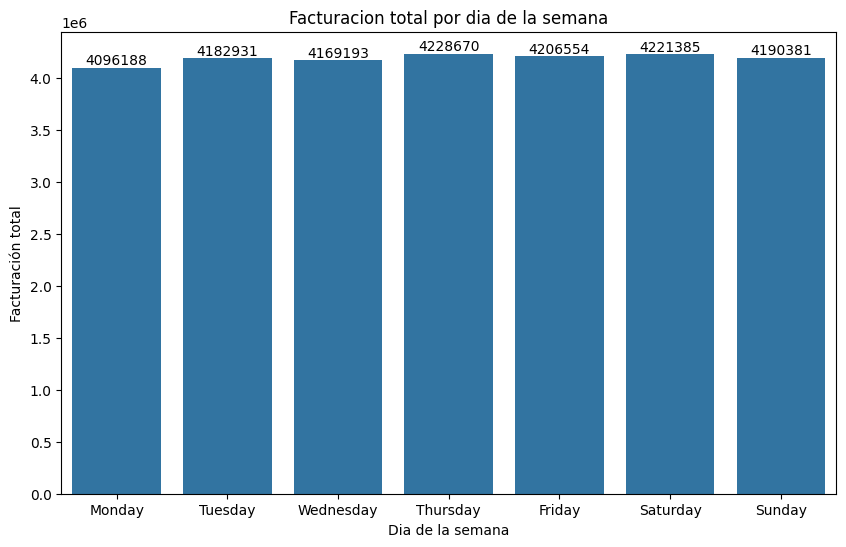

In [29]:
#creo el gráfico de barras
plt.figure(figsize=(10,6))
ax = sns.barplot(data=facturacion_dia_df, x="dia_semana", y="facturacion_total", order=dia_ordenado)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.0f')
plt.title("Facturacion total por dia de la semana")
plt.xlabel("Dia de la semana")
plt.ylabel("Facturación total")
plt.show()

La facturación total por día de la semana tampoco cambia mucho respecto al número de transacciones totales. El jueves sigue siendo el día que más factura (4.228.670), y el lunes el que menos(4.096.188), suponiendo una diferencia entre ambos días de 133.000€.

In [30]:
#ahora reviso el porcentaje de diferencia entre ambos datos
diferencia_facturacion = (4228670 - 4096188) / 4096188 * 100
diferencia_facturacion
print(f"La diferencia entre las ventas del lunes y el jueves es del {diferencia_facturacion:.2f}% ")

La diferencia entre las ventas del lunes y el jueves es del 3.23% 


Una vez calculada la diferencia porcentual entre la facturación del lunes y el jueves (la más alta y la más baja), se aprecia que la diferencia es de un 3,23%, indicando que no hay grandes cambios en cuanto a ventas a lo largo de la semana.

Este dato confirma lo que habíamos visualizado en el gráfico anterior, en que el lunes se situa como el día en que menos ventas y facturación se producen, y el jueves como el que más.

A pesar de ello, la diferencia es mínima, y hay una actividad homogenea a lo largo de la semana.

**Ejercicio 2** - Preguntas analíticas complejas

Aquí será necesario combinar información de diversas tablas del modelo para responder correctamente a las preguntas.

Necesitaré:

- Hacer merge entre tablas
- Usar grouby, pivot_table, crosstab...
- Aplicar agregaciones, transformaciones intermedias y funciones


  ¿Dependemos excesivamente de un número reducido de países de compañías vendedoras?

  Pasos orientativos:

  - Combinar la información de transactions con la de companyies
  - Agrupar la fucturación por país
  - Calcular la facturación total generada por cada país
  - Ordenar los países de mayor a menor facturación
  - Calcular el porcentaje acumulado sobre el total
  - Visualizar


In [31]:
#para este primer ejercicio, primero revisamos las tablas que se encuentran en la base de datos
from sqlalchemy import text#traductor/puente entre python y mysql
with engine.connect() as conn:
  result = conn.execute(text("SHOW TABLES;"))#ejecuto la consulta
  for row in result:
    print(row)

('companies',)
('credit_cards',)
('products',)
('transaction',)
('transaction_product',)
('users',)
('vistamarketing',)


In [32]:
#selecciono muestro la tabla companies solicitada para este ejercicio
tabla = "companies"
companies_df = pd.read_sql(tabla, engine)
companies_df.head()

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


In [33]:
#tipo de datos de la tabla
companies_df.dtypes

company_id                 str
company_name               str
phone                      str
email                      str
country                    str
website                    str
merchant_category          str
merchant_price_position    str
dtype: object

In [34]:
#revision composición dataframe
companies_df.shape

(100, 8)

In [35]:
#revision de datos nulos
companies_df.isnull().sum()

company_id                 0
company_name               0
phone                      0
email                      0
country                    0
website                    0
merchant_category          0
merchant_price_position    0
dtype: int64

In [36]:
#revisión de duplicados
companies_df.duplicated().sum()

np.int64(0)

In [37]:
#duplicados en la columna company_id
companies_df["company_id"].duplicated().sum()

np.int64(0)

In [38]:
#resumen de todas las columnas
companies_df.describe(include="all")

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
count,100,100,100,100,100,100,100,100
unique,100,100,100,100,15,100,10,3
top,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Sweden,https://www.ac-fermentum-incorporated.com,Electronics,mid-market
freq,1,1,1,1,11,1,15,51


In [39]:
#elementos de la columna
companies_df["country"].unique()


<StringArray>
[       'Germany',      'Australia',  'United States',    'New Zealand',
         'Norway', 'United Kingdom',          'Italy',        'Belgium',
         'Sweden',        'Ireland',          'China',         'Canada',
         'France',    'Netherlands',          'Spain']
Length: 15, dtype: str

In [40]:
#conteo de elementos únicos
companies_df["country"].nunique()

15

In [41]:
#comprobación de los datos company_id y business_id para unificarlas posteriormente
companies_df["company_id"].head()


0    b-2222
1    b-2226
2    b-2230
3    b-2234
4    b-2238
Name: company_id, dtype: str

In [42]:
df["business_id"].head()

0    b-2458
1    b-2390
2    b-2230
3    b-2266
4    b-2598
Name: business_id, dtype: str

In [43]:
#ahora que ya conocemos cómo es la tabla companies y qué contiene, hacemos el merge con la tabla transactions
merge_tablas = pd.merge(#unión de las do tablas con merge
    df,#tabla transaction
    companies_df,#tabla companies
    left_on="business_id",#cómo se unen las 2 tablas
    right_on="company_id",
    how="left"#coge la tabla transactions entera, aunque haya alguna clave que no coincida o no exista, seguirá mostrando la transacción
)

merge_tablas.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,estado_transaccion,dia_semana,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,Aceptada,Wednesday,b-2458,Eget Tincidunt Dui Institute,+18 210 327 5206,eget.laoreet@hotmail.org,Netherlands,https://www.eget-tincidunt-dui-institute.com,Toys,mid-market
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,Aceptada,Tuesday,b-2390,Neque Tellus Imperdiet Corp.,+12 445 145 3593,vestibulum.ante.ipsum@aol.edu,Ireland,https://www.neque-tellus-imperdiet-corp.com,Food,budget
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,Aceptada,Monday,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,Aceptada,Thursday,b-2266,Mus Aenean Eget Foundation,+1 504 922 3000,mi.duis@hotmail.net,Sweden,https://www.mus-aenean-eget-foundation.com,Sports,mid-market
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,Aceptada,Saturday,b-2598,Aliquam Iaculis Lacus Corp.,+23 674 242 3712,dictum@aol.org,Belgium,https://www.aliquam-iaculis-lacus-corp.com,Fashion,budget


In [44]:
#comprobación de la funcionalidad del merge
merge_tablas["country"].isnull().sum()

np.int64(0)

El 0 muestra que todas las transacciones encontraron a su empresa correspondiente, ninguna quedó sin país asignado


In [45]:
#agrupación facturación por país
facturacion_pais = merge_tablas.groupby("country")["amount"].sum()#agrupo por país y hago el sumatorio de amount
facturacion_pais = facturacion_pais.sort_values(ascending=False)#ordeno los resultados de mayor a menor
facturacion_pais

country
Sweden            4928117.68
Netherlands       4506571.38
United Kingdom    4099117.08
Italy             4087557.38
Germany           4020364.07
France            1416084.26
United States     1101737.27
Belgium            952208.75
Norway             809288.82
Ireland            715220.46
New Zealand        705159.09
Australia          699013.06
Canada             558568.76
Spain              457259.26
China              239034.47
Name: amount, dtype: float64

In [46]:
#sacamos el porcentaje de facturación individual por país
facturacion_pais_porcentaje = facturacion_pais / facturacion_pais.sum() * 100
facturacion_pais_porcentaje

country
Sweden            16.822212
Netherlands       15.383256
United Kingdom    13.992404
Italy             13.952945
Germany           13.723580
France             4.833827
United States      3.760798
Belgium            3.250380
Norway             2.762521
Ireland            2.441417
New Zealand        2.407072
Australia          2.386093
Canada             1.906684
Spain              1.560862
China              0.815948
Name: amount, dtype: float64

In [47]:
#sacamos el porcentaje acumulado
porcentaje_acumulado = facturacion_pais_porcentaje.cumsum()
porcentaje_acumulado

country
Sweden             16.822212
Netherlands        32.205468
United Kingdom     46.197872
Italy              60.150818
Germany            73.874397
France             78.708224
United States      82.469023
Belgium            85.719403
Norway             88.481924
Ireland            90.923341
New Zealand        93.330413
Australia          95.716506
Canada             97.623190
Spain              99.184052
China             100.000000
Name: amount, dtype: float64

El negocio muestra una dependencia significativa de un grupo reducido de países: 7 de los 15 países (menos del 50%) generan más del 80% de la facturación total, con Suecia y Países Bajos como los dos mercados más críticos (32% combinado). Esto representa un riesgo de concentración geográfica — cualquier problema regulatorio, económico o operativo en estos mercados clave tendría un impacto desproporcionado en el negocio. Se recomienda evaluar estrategias de diversificación hacia mercados actualmente menores.

In [48]:
#para visualizar estos datos, usaré un gráfico de pareto que muestra la facturación por país, y una línea con el porcentaje acumulado
#primero, pasamos las listas a fataframe para que matplotlib pueda coger los datos
pareto_df = facturacion_pais.reset_index()#reset_index() para pasar a dataframe
pareto_df.columns = ["country","facturacion"]#renombro columna amount a facturacion
pareto_df["porcentaje_acumulado"] = porcentaje_acumulado.values#añado otra columna con los valores obtenidos en porcentaje_acumulado
pareto_df

,country,facturacion,porcentaje_acumulado
0,Sweden,4928117.68,16.822212
1,Netherlands,4506571.38,32.205468
2,United Kingdom,4099117.08,46.197872
3,Italy,4087557.38,60.150818
4,Germany,4020364.07,73.874397
5,France,1416084.26,78.708224
6,United States,1101737.27,82.469023
7,Belgium,952208.75,85.719403
8,Norway,809288.82,88.481924
9,Ireland,715220.46,90.923341


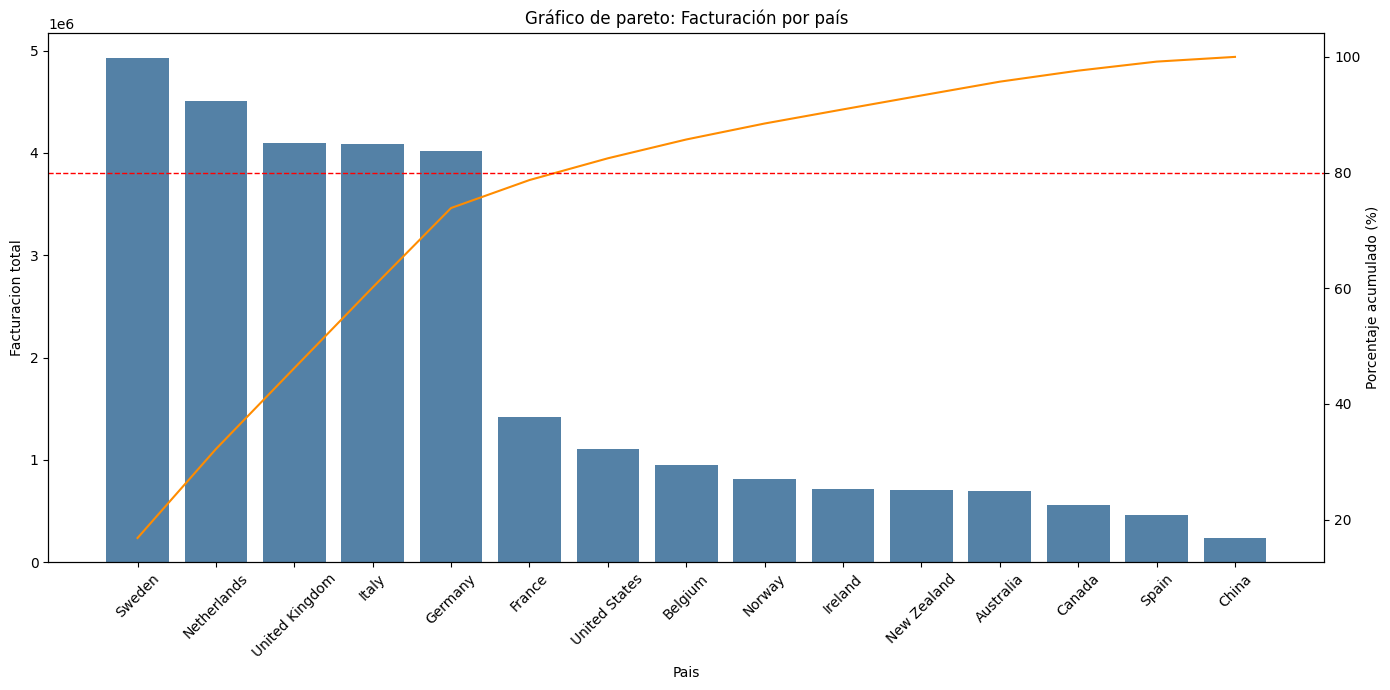

In [49]:
#código para sacar el gráfico
fig, ax1 = plt.subplots(figsize=(14,7))
sns.barplot(data=pareto_df, x="country", y="facturacion", ax=ax1, color="steelblue")
ax1.set_xlabel("Pais")
ax1.set_ylabel("Facturacion total")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(pareto_df["country"], pareto_df["porcentaje_acumulado"], color="darkorange")
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.axhline(80, color="red", linestyle="--", linewidth=1)

plt.title("Gráfico de pareto: Facturación por país")
plt.tight_layout()
plt.show()

En la gráfica se ve claramente la diferencia de facturación por países. A primera vista se aprecia una gran descompensación. Los 5 primeros países suponen más del 70% de las ventas, por lo que el negocio depende en un porcentaje muy alto de 5 países.
Además, la facturación entre el quinto país que más factura (Alemania) y el sexto (Francia) es de alrededor 2.6 millones de euros.
La línea muestra el porcentaje acumulado, vemos un pico importante entre los primeros 5 países, que acaba estabilizándose y aplanándose a medida que la facturación disminuye.
Este dato puede suponer un peligro para el negocio, ya que al depender mayoritariamente de 5 países (y todos situados en el mismo continente), están sujetos a posibles adversidades económicas (recesiones económicas, cambios regulatorios) que tendrian un gran impacto en el negocio.
Sería recomentable tratar de aumentar las facturaciones en otros países (a poder ser en otros continentes), que mitiguen la dependencia absoluta de 5 países, pudiendo minimar adversidades económicas o políticas que puedan darse.

¿Existe estacionalidad de ventas?

Pasos orientativos:
- Trabajar con datos de Transaction
- Extraer información relevante (año y mes)
- Calcular el volumen total de ventas (suma de amount) por año y mes
- Comparar patrones temporales con la comparación entre añis. Crea una tabla tipo pivot
- Visualizar la evolución


In [50]:
#extracción de mes y año
merge_tablas["anyo"] = merge_tablas["timestamp"].dt.year
merge_tablas["mes"] = merge_tablas["timestamp"].dt.month
merge_tablas[["timestamp","anyo","mes"]].head()

,timestamp,anyo,mes
0,2024-08-28 07:16:46,2024,8
1,2020-07-14 15:37:45,2020,7
2,2017-09-04 19:44:53,2017,9
3,2017-01-05 18:19:25,2017,1
4,2023-09-23 04:51:43,2023,9


In [51]:
#calcular el volumen total de ventas por año y mes
volumen_ventas = merge_tablas.groupby(["anyo","mes"])["amount"].sum()
volumen_ventas

anyo  mes
2015  1      224946.23
      2      248775.83
      3      254702.98
      4      247957.49
      5      252596.43
               ...    
2024  8      239210.63
      9      236592.54
      10     255720.13
      11     236354.15
      12     251688.94
Name: amount, Length: 120, dtype: float64

In [52]:
#creación de la tabla dinámica
tabla_dinamica = merge_tablas.pivot_table(#método para crear la tabla dinámica con pivot_table
    index="mes",#los meses serán el index
    columns="anyo",#columnas serán los años
    values="amount",#los valores con los que rellenerá la tabla
    aggfunc="sum"#suma transacciones de ese mes y año
)
tabla_dinamica

anyo,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
mes,,,,,,,,,,
1,224946.23,227231.14,224391.23,229524.09,224592.71,234191.13,246993.53,226680.93,231075.91,227399.39
2,248775.83,251111.47,253354.90,246504.98,262006.66,249356.44,258837.10,237503.38,252680.15,253739.68
3,254702.98,248245.83,240338.05,239145.90,280530.50,260821.35,253110.77,274387.47,243909.57,248588.94
4,247957.49,242394.40,253125.97,237432.05,244347.66,246533.40,261597.02,241191.04,245386.83,245734.27
5,252596.43,243533.92,240919.28,246838.08,244739.50,254171.48,243414.73,279590.23,264790.26,257877.46
6,233084.63,233245.79,241065.64,243421.44,245470.13,238902.90,236504.81,261954.89,234527.22,247029.50
7,243774.43,238618.15,244380.32,233449.29,233962.91,242644.23,253553.62,235935.19,240041.34,231264.22
8,238550.36,238392.03,233894.55,231129.56,240040.21,234433.92,239433.71,246434.63,239288.98,239210.63
9,227985.24,242774.67,235830.55,238772.22,235021.45,258779.26,247648.05,255496.48,237105.34,236592.54


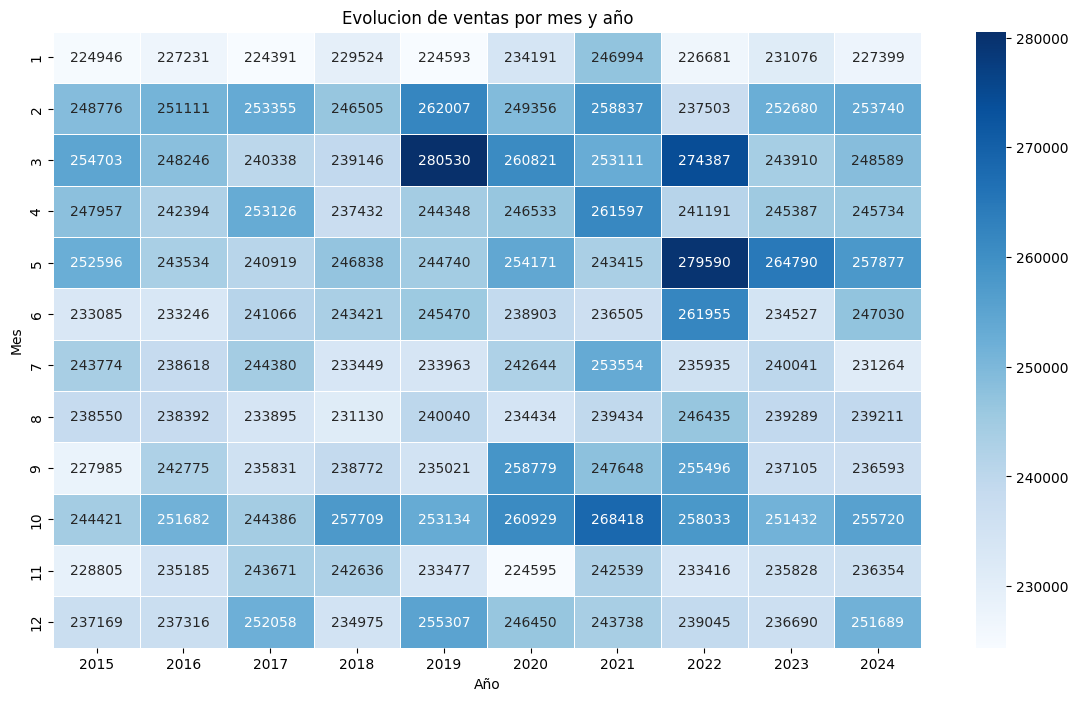

In [53]:
#gráfico para visualizar la evolución por mes
plt.figure(figsize=(14,8))
sns.heatmap(tabla_dinamica, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5)#annot=True muestra el valor dentro de cada celda
plt.title("Evolucion de ventas por mes y año")
plt.xlabel("Año")
plt.ylabel("Mes")
plt.show()

El análisis de estacionalidad no revela patrones consistentes entre años: no existen meses que sistemáticamente generen más o menos ventas de forma predecible. La variabilidad observada (entre ~225.000€ y ~280.000€) parece más bien fluctuación natural/aleatoria que un patrón estacional real. Esto sugiere que el negocio no depende de campañas estacionales (como Navidad, verano, Black Friday, etc.) y que la demanda es estructuralmente estable a lo largo del año — coherente con lo que ya observamos en la evolución mensual y en la distribución por días de la semana del ejercicio anterior

Análisis de concentración y variabilidad.

Actividad de los usuarios

¿Hay usuarios que han dejado de comprar recientemente?
Pasos orientativos a seguir:
- Identificar la última compra de cada usuario
- Calcular le tiempo desde la última compra
- Visualizar la distribución del tiempo desde la última compra

In [54]:
from sqlalchemy import text#traductor/puente entre python y mysql
with engine.connect() as conn:
  result = conn.execute(text("SHOW TABLES;"))#ejecuto la consulta
  for row in result:
    print(row)

('companies',)
('credit_cards',)
('products',)
('transaction',)
('transaction_product',)
('users',)
('vistamarketing',)


In [55]:
#última transacción pos cliente
ultima_compra = df.groupby("user_id")["timestamp"].max()#.max saca la fecha más reciente
ultima_compra

user_id
1      2024-11-15 14:48:20
2      2024-04-20 06:41:27
3      2024-02-22 03:31:36
4      2024-12-29 11:47:48
5      2024-05-02 21:11:06
               ...        
4996   2023-06-22 13:59:16
4997   2024-10-05 10:01:11
4998   2024-12-09 19:48:11
4999   2024-08-04 04:51:44
5000   2024-11-24 23:28:38
Name: timestamp, Length: 5000, dtype: datetime64[us]

Observamos que la fecha de la última compra del dataset (el último registro) es de diciembre de 2024, por tanto, usaremos 2024 como referencia

In [56]:
fecha_referencia = df["timestamp"].max()
fecha_referencia

Timestamp('2024-12-31 23:31:55')

In [57]:
#restamos la última fecha del dataset, con la fecha de de la última compra por usuario, y lo pasamos a días
dias_sin_comprar = (fecha_referencia - ultima_compra).dt.days
dias_sin_comprar

user_id
1        46
2       255
3       313
4         2
5       243
       ... 
4996    558
4997     87
4998     22
4999    149
5000     37
Name: timestamp, Length: 5000, dtype: int64

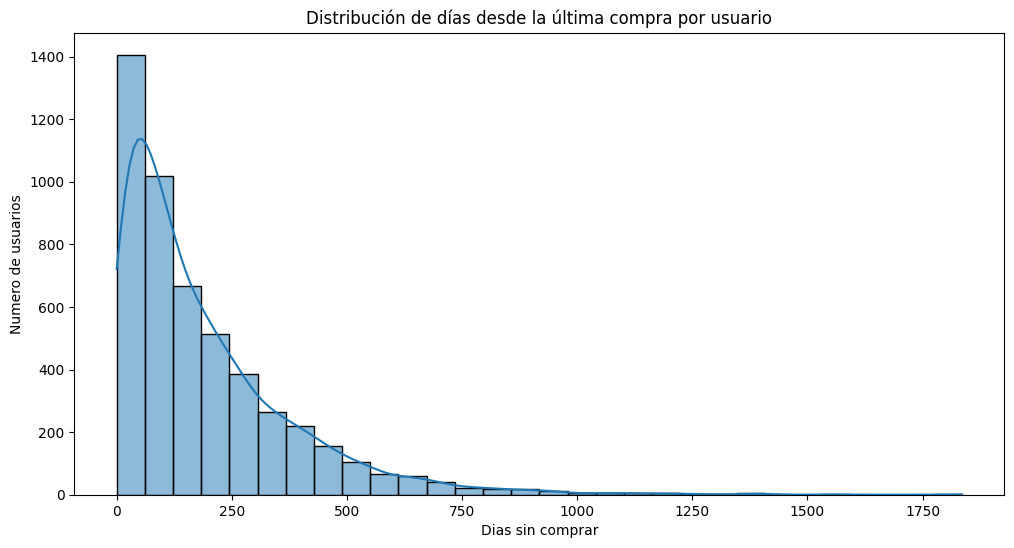

In [58]:
#gráfico de los datos
plt.figure(figsize=(12,6))
sns.histplot(dias_sin_comprar,bins=30, kde=True)
plt.title("Distribución de días desde la última compra por usuario")
plt.xlabel("Dias sin comprar")
plt.ylabel("Numero de usuarios")
plt.show()

La distribución de días desde la última compra, muestra una caída exponencial: la mayoría de usuarios tiene actividad reciente (el pico más alto se concentra en los primeros 100 días) y a medida que aumentan los días de inactividad, el número de usuarios en esa situación disminuye progresivamente. Aun así, existe una cola larga de usuarios que llevan mucho tiempo sin comprar, extendiéndose hasta más de 1.500 días (más de 4 años) en los casos más extremo.

In [59]:
#usuarios en riesgo o inactivos según diferentes umbrales
usuarios_90_dias = (dias_sin_comprar > 90).sum()
usuarios_180_dias = (dias_sin_comprar > 180).sum()
usuarios_365_dias = (dias_sin_comprar > 365).sum()

print(f"Usuarios sin comprar hace más de 90 días: {usuarios_90_dias} ({usuarios_90_dias/5000*100:.1f}%)")
print(f"Usuarios sin comprar hace más de 180 días: {usuarios_180_dias} ({usuarios_180_dias/5000*100:.1f}%)")
print(f"Usuarios sin comprar hace más de 365 días: {usuarios_365_dias} ({usuarios_365_dias/5000*100:.1f}%)")

Usuarios sin comprar hace más de 90 días: 3081 (61.6%)
Usuarios sin comprar hace más de 180 días: 1938 (38.8%)
Usuarios sin comprar hace más de 365 días: 750 (15.0%)


Con los umbrales calculados, podemos cuantificar esta inactividad:

El 61.6% de los usuarios no ha comprado en los últimos 90 días.
El 38.8% lleva más de 180 días (6 meses) sin comprar.
El 15% (750 usuarios) lleva más de un año sin ninguna compra.

Este último grupo es el más relevante: un año entero de inactividad, independientemente de la frecuencia de compra habitual del negocio, es un plazo suficientemente largo como para considerar a estos usuarios como clientes probablemente perdidos, y no simplemente clientes de compra ocasional.

Implicación para negocio:

Estos datos permiten segmentar a la base de clientes según su riesgo de fuga y diseñar una estrategia de reactivación escalonada:

90-180 días de inactividad: contacto temprano (recordatorios, newsletters) para evitar que se conviertan en clientes perdidos.

+180 días: campañas más específicas de reenganche (descuentos, ofertas personalizadas).

+365 días: considerar estos 750 usuarios como clientes en alto riesgo de abandono definitivo — priorizar acciones de recuperación agresivas o, si el coste de reactivación no compensa, reasignar recursos de marketing hacia la adquisición de nuevos clientes.

¿Cómo varía la actividad de venta por franjas horarias a lo largo de los años? (patrones horarios)

Pasos orientativos:

- Crear franjas horarias a partir de la hora: crea una función y aplícala usando apply
- Construir una tabla agregada usando crosstab
- Visualizar con un heatmap


In [60]:
#creación de las franjas horarias
df["hora"] = df["timestamp"].dt.hour
df["anyo"] = df["timestamp"].dt.year

In [61]:
#creación de la función con apply
def franja_horaria(hora):#creo la funcion franja_horaria que al recibir un  numero (una hora) devuelve la franja horaria en la que se encuentra
  if 0 <= hora < 6:
    return "madrugada"
  elif 6 <= hora < 12:
    return "mañana"
  elif 12 <= hora < 18:
    return "tarde"
  else:
    return "noche"

df["franja"] = df["hora"].apply(franja_horaria)#creo la columna franja en el dataset, cojo la columna hora y le aplico la función
df[["hora","franja"]].head()#muestro las columnas

,hora,franja
0,7,mañana
1,15,tarde
2,19,noche
3,18,noche
4,4,madrugada


In [62]:
#tabla agregada con crosstab
tabla_crosstab = pd.crosstab(df["anyo"], df["franja"])
tabla_crosstab

franja,madrugada,mañana,noche,tarde
anyo,,,,
2015,2452,2461,2500,2457
2016,2474,2481,2389,2510
2017,2444,2476,2441,2554
2018,2523,2425,2456,2508
2019,2467,2554,2450,2544
2020,2615,2471,2535,2472
2021,2589,2584,2532,2593
2022,2569,2457,2560,2520
2023,2516,2551,2454,2464


La tabla crosstab cuenta frecuencias (cuantas veces aparece la combinación de varias categorías.

En este caso muestra cuantas transacciones hubo por franja y en cada año.

A simple vista, los datos parecen homogeneos, pero vamos a verlo representado con un heatmap

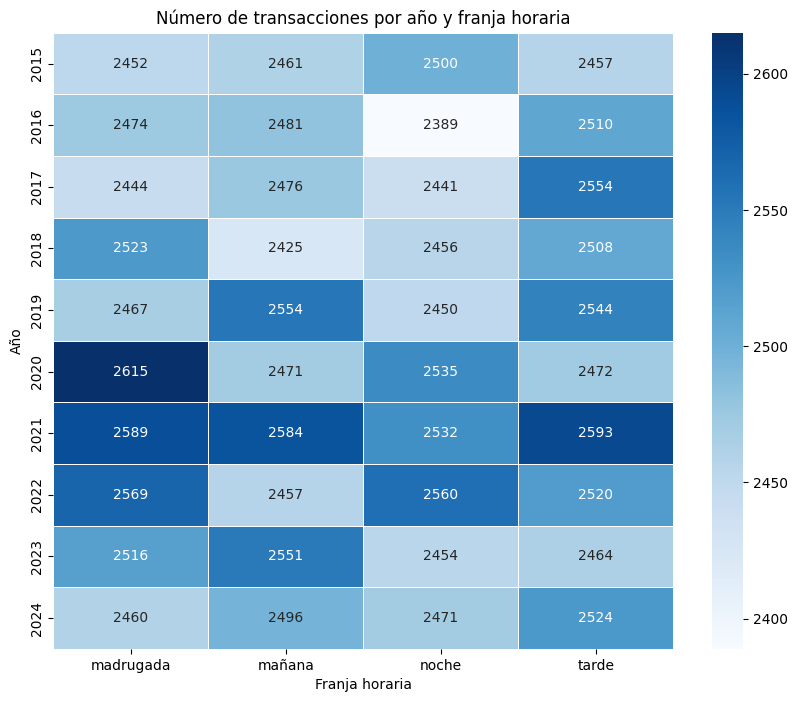

In [63]:
#visualizacion datos
plt.figure(figsize=(10,8))
sns.heatmap(tabla_crosstab, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Número de transacciones por año y franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Año")
plt.show()

La actividad de venta se mantiene homogénea entre las distintas franjas horarias a lo largo de los 10 años analizados, sin un patrón horario dominante claro. Se observa un ligero repunte de actividad en 2020-2021, especialmente en franjas de madrugada y tarde, que podría estar relacionado con cambios en los hábitos de consumo durante el periodo de pandemia (mayor tiempo en casa, horarios más flexibles). En conjunto, el negocio no muestra dependencia de ninguna franja horaria específica, lo que sugiere flexibilidad operativa (no haría falta concentrar recursos en un horario concreto).

El repunte en madrugada durante 2020-2021 podría deberse a alteraciones en los hábitos de sueño y rutinas durante la pandemia, aunque también podría reflejar la distribución horaria de clientes internacionales en distintas zonas horarias. Sin datos adicionales sobre la ubicación exacta del comprador en el momento de la compra, no es posible confirmar la causa concreta.

**Nivel 2** - Análisis relacional y patrones avanzados

**Ejercicio 1** - Análisis de productos y captación de usuarios

Actualizar el rendimiento de los productos combinando ingresos, estabilidad y capacidad de captación de nuevos usuarios, con el objetivo de detectar posibles riesgos de negocio asociados a concentración excesiva de ingresos, dependencia de usuarios recurrentes y falta de crecimiento en base de usuarios.

Los productos que generan más ingresos también impulsan el crecimiento del negocio mediante la captación de nuevos usuarios, o bien el negocio depende principalmente de usuarios recurrentes comprando los mismos productos?

Pasos orientativos:

- Combina las tablas necesarias
- Define un criterio de nuevo usuario si la transacción analizada es la primera cronológicamente que realiza al sistema es_nou_usuari =  True / False.

In [64]:
#muestro las tablas que contiene la base de datos
from sqlalchemy import text#traductor/puente entre python y mysql
with engine.connect() as conn:
  result = conn.execute(text("SHOW TABLES;"))#ejecuto la consulta
  for row in result:
    print(row)

('companies',)
('credit_cards',)
('products',)
('transaction',)
('transaction_product',)
('users',)
('vistamarketing',)


In [65]:
products_df = pd.read_sql("products", engine)
products_df.head()

,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,1,Direwolf Stannis,$161.11,#7c7c7c,1.0,WH-4,Sports,Runway Pro,$63.84,2014-11-01
1,2,Tarly Stark,$9.24,#919191,2.0,WH-3,Gaming,Questbyte,$4.74,2013-02-07
2,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,$107.07,2013-08-18
3,4,warden south duel,$71.89,#111111,3.0,WH-1,Books,NorthPress,$39.17,2013-12-31
4,5,skywalker ewok,$171.22,#dbdbdb,3.2,WH-0,Home,NordHaus,$83.69,2014-07-17


In [66]:
#compruebo el tipo de dato que es la columna product_ids y veo que es un string
df["product_ids"].dtype

<StringDtype(storage='python', na_value=nan)>

In [67]:
#muestro la tabla transaction de nuevo, la columna product_ids está agrupada, por lo que hay que generar una fila con todos los datos por producto
df.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,device_type,is_international,decline_reason,distance_km,mes,hora,estado_transaccion,dia_semana,anyo,franja
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,mobile,0,,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,pos,1,,1157.10,2020-07,15,Aceptada,Tuesday,2020,tarde
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,pos,0,,540.32,2017-09,19,Aceptada,Monday,2017,noche
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,desktop,0,,28.52,2017-01,18,Aceptada,Thursday,2017,noche
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,pos,0,,539.82,2023-09,4,Aceptada,Saturday,2023,madrugada


In [68]:
#debido a que la tabla transaction tiene la columna product_ids agrupada, y en el ejercicio pide por transacción, hay que separar los ids y convertir cada producto en una fila
#primero, convertimos el string en una lista con split, para después poder romperlo con explode
df["product_ids_lista"] = df["product_ids"].str.split(",")#creo la columna product_ids_lista donde guardo una lista con los string separados por coma
df[["product_ids","product_ids_lista"]].head()#muestro las dos columnas, una con string, y la otra una lista

,product_ids,product_ids_lista
0,"16, 26, 97, 87","[16, 26, 97, 87]"
1,"30, 11, 16, 81","[30, 11, 16, 81]"
2,72,[72]
3,18,[18]
4,"35, 33, 19","[35, 33, 19]"


In [69]:
#explotar la lista en filas separadas

id_explotado = df.explode("product_ids_lista")#uso el metodo explode de la columna product_ids_lista para que los separe por filas
id_explotado[["id","product_ids","product_ids_lista"]].head(10)#muestro las columnas product_ids y product_ids_lista, además de id, para ver que se han separado las transacciones correctamente en filas

,id,product_ids,product_ids_lista
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,"16, 26, 97, 87",16
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,"16, 26, 97, 87",26
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,"16, 26, 97, 87",97
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,"16, 26, 97, 87",87
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,"30, 11, 16, 81",30
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,"30, 11, 16, 81",11
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,"30, 11, 16, 81",16
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,"30, 11, 16, 81",81
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,72,72
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,18,18


Debido a que la columna product_ids era un string, que contenía varios product ids para una misma transacción (1 transacción ha hecho 1 compra de varios productos), hemos procedido a usar el método split y luego explode, con el objetivo de separar las transacciones por filas, para hacer más fácil el conteo de productos final.
El resultado final muestra el id (la transacción repedita) por id de producto comprado.

In [70]:
#reviso si hay espacios entre los strings de la columna nueva con los ids. Se desprende que los ids que iban en primer lugar, no tienen espacios, pero los que iban detrás de las comas sí. por tan es necesario eliminar los espacios para evitar problemas con el merge con otras tablas
sorted(id_explotado["product_ids_lista"].unique())

[' 1',
 ' 10',
 ' 100',
 ' 11',
 ' 12',
 ' 13',
 ' 14',
 ' 15',
 ' 16',
 ' 17',
 ' 18',
 ' 19',
 ' 2',
 ' 20',
 ' 21',
 ' 22',
 ' 23',
 ' 24',
 ' 25',
 ' 26',
 ' 27',
 ' 28',
 ' 29',
 ' 3',
 ' 30',
 ' 31',
 ' 32',
 ' 33',
 ' 34',
 ' 35',
 ' 36',
 ' 37',
 ' 38',
 ' 39',
 ' 4',
 ' 40',
 ' 41',
 ' 42',
 ' 43',
 ' 44',
 ' 45',
 ' 46',
 ' 47',
 ' 48',
 ' 49',
 ' 5',
 ' 50',
 ' 51',
 ' 52',
 ' 53',
 ' 54',
 ' 55',
 ' 56',
 ' 57',
 ' 58',
 ' 59',
 ' 6',
 ' 60',
 ' 61',
 ' 62',
 ' 63',
 ' 64',
 ' 65',
 ' 66',
 ' 67',
 ' 68',
 ' 69',
 ' 7',
 ' 70',
 ' 71',
 ' 72',
 ' 73',
 ' 74',
 ' 75',
 ' 76',
 ' 77',
 ' 78',
 ' 79',
 ' 8',
 ' 80',
 ' 81',
 ' 82',
 ' 83',
 ' 84',
 ' 85',
 ' 86',
 ' 87',
 ' 88',
 ' 89',
 ' 9',
 ' 90',
 ' 91',
 ' 92',
 ' 93',
 ' 94',
 ' 95',
 ' 96',
 ' 97',
 ' 98',
 ' 99',
 '1',
 '10',
 '100',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',


In [71]:
#eliminación de los espacios de la columna ids
id_explotado["product_ids_lista"] = id_explotado["product_ids_lista"].str.strip()#selecciono la columna product_ids_lista y le paso el metodo strip para eliminar los espacios

In [72]:
#muestro la columna y veo que los espacios se han eliminado correctamente
sorted(id_explotado["product_ids_lista"].unique())

['1',
 '10',
 '100',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '4',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '5',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '6',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '7',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '8',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '9',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99']

In [73]:
#para preparar el merge de las tablas, reviso el tipo de datos de ambas tablas, y veo que son diferentes, uno es entero y el otro string, por tanto hace falta modificar el dato para que sean iguales y que no genere errores

print(products_df["id"].dtypes)
print(id_explotado["product_ids_lista"].dtype)

int64
str


In [74]:
#procedo a cambiar el tipo de dato, de string a int64
id_explotado["product_ids_lista"] = id_explotado["product_ids_lista"].astype(int)#selecciono la columna y la cambio con astype(int) para que el dato sea igual al de la otra tabla
id_explotado["product_ids_lista"].dtype

dtype('int64')

In [75]:
#procedo al merge de las tablas
transacciones_productos = pd.merge(#uso el método merge y elijo las tablas que quiero mezclar
    id_explotado,#tabla izquierda
    products_df,#tabla derecha
    left_on="product_ids_lista",
    right_on="id",
    how="left"#tabla de la izquierda para contener todas las transacciones
)
transacciones_productos.head()

,id_x,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,16,the duel warden,$180.91,#666666,3.0,WH-11,Home,NordHaus,$101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,26,Stark Karstark,$53.01,#898989,2.0,WH-21,Food,GreenFork,$30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,97,jinn Winterfell,$65.25,#bababa,1.0,WH-92,Beauty,CareLab,$26.25,2013-02-22
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,87,sith Jade,$96.26,#e2e2e2,1.5,WH-82,Food,Market&Co,$66.36,2013-11-10
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,30,Karstark warden,$79.53,#606060,0.8,WH-25,Electronics,Nexa,$50.18,2013-02-06


In [76]:
id_explotado.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,is_international,decline_reason,distance_km,mes,hora,estado_transaccion,dia_semana,anyo,franja,product_ids_lista
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana,16
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana,26
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana,97
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,0,,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana,87
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,1,,1157.10,2020-07,15,Aceptada,Tuesday,2020,tarde,30


Como se muestra, el merge de ambas tablas ha fucnionado bien, se han juntado los datos en un nuevo dataframe que se llama transacciones_productos. Se puede apreciar que, en las dos tablas existia una columna que se llama id, al hacer el merge, Python ha renombrado una a id_x, y la otra a id_y. id_x hace referencia al id de la transacción, y el id_y al id del producto

In [77]:
#antes de seguir, compruebo que no se haya quedado ningún dato vacío
transacciones_productos["product_name"].isnull().sum()

np.int64(0)

In [78]:
#Además, para evitar errores, voy a modificar el nombre de las columnas repetidas id_x e id_y, para hacerlo más fácil y evitar errores
transacciones_productos = transacciones_productos.rename(columns={
    "id_x" : "transaction_id",
    "id_y" : "product_id"
})
transacciones_productos.head()

,transaction_id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,product_id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,16,the duel warden,$180.91,#666666,3.0,WH-11,Home,NordHaus,$101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,26,Stark Karstark,$53.01,#898989,2.0,WH-21,Food,GreenFork,$30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,97,jinn Winterfell,$65.25,#bababa,1.0,WH-92,Beauty,CareLab,$26.25,2013-02-22
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,87,sith Jade,$96.26,#e2e2e2,1.5,WH-82,Food,Market&Co,$66.36,2013-11-10
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,30,Karstark warden,$79.53,#606060,0.8,WH-25,Electronics,Nexa,$50.18,2013-02-06


In [79]:
#encontrar la fecha de la primera transacción de cara usuario. para ello uso el dataset inicial, sin explotar el product_ids, con el objetivo de simplificar la visualización
primera_compra = df.groupby("user_id")["timestamp"].min()
primera_compra.head()

user_id
1   2015-05-08 18:09:41
2   2015-01-13 05:50:19
3   2015-05-04 10:23:38
4   2015-10-25 18:43:29
5   2015-03-28 04:50:05
Name: timestamp, dtype: datetime64[us]

In [80]:
#mapeo de compras. marco cada compra por si es la primera o no
df["fecha_primera_compra"] = df["user_id"].map(primera_compra)#uso la columna user_id para mapear la primera fecha en que se realiza una compra
df["es_nuevo_usuario"] = df["timestamp"] == df["fecha_primera_compra"]#comparo fila a fila la fecha de la compra, con la de la primera compra para que coincida en si es la primera, es usuario nuevo (True)
df[["user_id","timestamp","fecha_primera_compra","es_nuevo_usuario"]].head(10)

,user_id,timestamp,fecha_primera_compra,es_nuevo_usuario
0,4713,2024-08-28 07:16:46,2015-02-06 02:39:31,False
1,2118,2020-07-14 15:37:45,2015-08-03 18:53:18,False
2,2115,2017-09-04 19:44:53,2016-01-19 04:28:25,False
3,3025,2017-01-05 18:19:25,2015-01-13 09:37:42,False
4,215,2023-09-23 04:51:43,2015-03-04 10:31:44,False
5,2928,2023-12-31 00:06:36,2015-05-23 12:37:17,False
6,3902,2017-07-18 07:52:02,2015-05-04 02:09:36,False
7,1886,2018-09-08 05:29:58,2016-07-11 23:25:13,False
8,1385,2022-09-17 04:02:19,2015-03-12 19:23:55,False
9,42,2020-02-07 23:03:45,2015-03-10 01:35:30,False


In [81]:
df["es_nuevo_usuario"].sum()
#comprobación de que ha funcionado y que muestra los usuarios nuevos. coincide con los 5000 usuarios registrados, ya que todos tienen, al menos, 1 compra

np.int64(5000)

Debido a que hemos añadido la columna booleana es_nuevo_usuario, vamos a realizar el proceso de explode de product_ids hecho anteriormente, para que de esta manera, hacer un proceso limpio que incluya todos los requisitos del ejercicio

In [82]:
#separacion product_ids en listas
df["product_ids_lista"] = df["product_ids"].str.split(",")#lo separo por comas y hago una lista
#explotación de lista en filas
id_explotado = df.explode("product_ids_lista")
#limpieza de espacios
id_explotado["product_ids_lista"] = id_explotado["product_ids_lista"].str.strip()
#conversion a entero
id_explotado["product_ids_lista"] = id_explotado["product_ids_lista"].astype(int)
#merge con la tabla productos
transacciones_productos = pd.merge(
    id_explotado,
    products_df,
    left_on="product_ids_lista",
    right_on="id",
    how="left"
)
#renombrar columnas ambiguas
transacciones_productos = transacciones_productos.rename(columns={
    "id_x" : "transaction_id",
    "id_y" : "product_id"
})
transacciones_productos.head()

,transaction_id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,product_id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,16,the duel warden,$180.91,#666666,3.0,WH-11,Home,NordHaus,$101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,26,Stark Karstark,$53.01,#898989,2.0,WH-21,Food,GreenFork,$30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,97,jinn Winterfell,$65.25,#bababa,1.0,WH-92,Beauty,CareLab,$26.25,2013-02-22
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,87,sith Jade,$96.26,#e2e2e2,1.5,WH-82,Food,Market&Co,$66.36,2013-11-10
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,30,Karstark warden,$79.53,#606060,0.8,WH-25,Electronics,Nexa,$50.18,2013-02-06


In [83]:
#comprobación de que ha salido bien y que no quedan datos nulos
print(transacciones_productos["product_name"].isnull().sum())#suma de nulos en productos
print(transacciones_productos["es_nuevo_usuario"].value_counts())#conteo de nuevos usuarios

0
es_nuevo_usuario
False    240861
True      12527
Name: count, dtype: int64


El dataset ofrece dos columnas relacionadas con el importe: amount y price. Sin embargo, amount corresponde al total de la transacción completa (que puede incluir varios productos), por lo que no permite conocer cuánto se pagó por cada producto individualmente. Por ello, para calcular los ingresos por producto usamos price (el precio de catálogo de cada producto), asumiendo que cada aparición del producto en una transacción representa la venta de una unidad a su precio de lista. Esta aproximación no refleja posibles descuentos aplicados en la transacción real, pero es la mejor estimación disponible con los datos que tenemos.

In [84]:
print(transacciones_productos["price"].head())#revisamos cómo se muestra el dato
print(transacciones_productos["price"].dtype)#revisamos el tipo de dato

0    $180.91
1     $53.01
2     $65.25
3     $96.26
4     $79.53
Name: price, dtype: str
str


In [85]:
#price es texto (string) por tanto hay que pasarlo a decimal (float), y limpiar el símbolo inicial de $
transacciones_productos["precio_limpio"] = transacciones_productos["price"].str.replace("$","",regex=False).astype(float)
transacciones_productos["precio_limpio"].head()

0    180.91
1     53.01
2     65.25
3     96.26
4     79.53
Name: precio_limpio, dtype: float64

Agrega la información por producto y calcula las siguientes métricas:

- Cálculo de ingresos totales
- Variabilidad de los ingresos
- Número de nuevos usuarios
- Porcentaje de nuevos usuarios sobre el total de compradores del producto

Para llevar a cabo este ejercicio, voy a realizar una función agregada para hace los cálculos en una misma celda

In [86]:
#para evitar errores, cogeremos los productos que no hayan sido rechazados
productos_aceptados = transacciones_productos[transacciones_productos["declined"] == 0]

In [87]:
#función agregada para hacer los cálculos solicitados
resumen_productos = productos_aceptados.groupby(["product_id","product_name"]).agg(#creo la función agregado usando las columnas product_id y product_name para agrupar
    ingresos_totales = ("precio_limpio","sum"),#hago la suma de precio limpio para los ingresos totales
    variabilidad_ingresos = ("precio_limpio","std"),#desviación estándar de precio limpio
    num_usuarios_totales = ("user_id","nunique"),#el total de usuarios únicos
    num_usuarios_nuevos = ("es_nuevo_usuario","sum")#la suma de nuevos usuarios
).reset_index()#lo paso a dataframe

#cálculo de porcentaje de usuarios nuevos
resumen_productos["procentaje_u_nuevos"] = (#creacion columna porcentaje usuarios nuevos
    resumen_productos["num_usuarios_nuevos"] / resumen_productos["num_usuarios_totales"] * 100#usuarios nuevos entre los totales multiplicado por 100
)
resumen_productos.head()


,product_id,product_name,ingresos_totales,variabilidad_ingresos,num_usuarios_totales,num_usuarios_nuevos,procentaje_u_nuevos
0,1,Direwolf Stannis,394719.50,0.0,1890,108,5.714286
1,2,Tarly Stark,23580.48,0.0,1949,125,6.413545
2,3,duel tourney Lannister,429022.91,0.0,1921,126,6.559084
3,4,warden south duel,184254.07,0.0,1945,120,6.169666
4,5,skywalker ewok,433186.60,0.0,1932,150,7.763975


Creación de una tipología analítica de productos a partir de de las métricas calculadas, por ejemplo:
- Captación : alta captación de nuevos usuarios
- Recurrente : ingresos elevados pero baja captación
- Emergente : baja facturación pero buena captación
- Estancado: bajos ingresos y baja captación

In [88]:
#definición de umbrales de referencia, usando la mediana
mediana_ingresos = resumen_productos["ingresos_totales"].median()
mediana_captacion = resumen_productos["num_usuarios_nuevos"].median()

In [89]:
#definición de la función de la clasificación
def clasificacion_producto(row):
  #añado los umbrales creados a dos variables
  alto_ingreso = row["ingresos_totales"] >= mediana_ingresos
  alta_captacion = row["num_usuarios_nuevos"] >= mediana_captacion

  if alto_ingreso and alta_captacion:
    return "Captador"#elevados ingresos y elevada captación
  elif alto_ingreso and not alta_captacion:
    return "Recurrente"#elevados ingresos pero baja captación
  elif not alto_ingreso and alta_captacion:
    return "Emergente"#baja facturacion pero alta captación
  else:
    return "Estancado"#baja facturación y baja captación

#creación columna tipo y aplicación de la función
resumen_productos["tipologia"] = resumen_productos.apply(clasificacion_producto, axis=1)  #axis=1 indica a pandas que lea horizontalmente (filas)

#conteo de tipología de productos
resumen_productos["tipologia"].value_counts()

tipologia
Emergente     28
Recurrente    26
Captador      24
Estancado     22
Name: count, dtype: int64

Construye una visualización que permita analizar la relación entre las principales dimensiones. Por ejemplo, un scatter plot con:
- Eje X --> ingresos totales por productos
- Eje Y --> número de nuevos usuarios
- Media del punto --> variabilidad de los ingresos
- Color del punto --> tipología analítica del producto


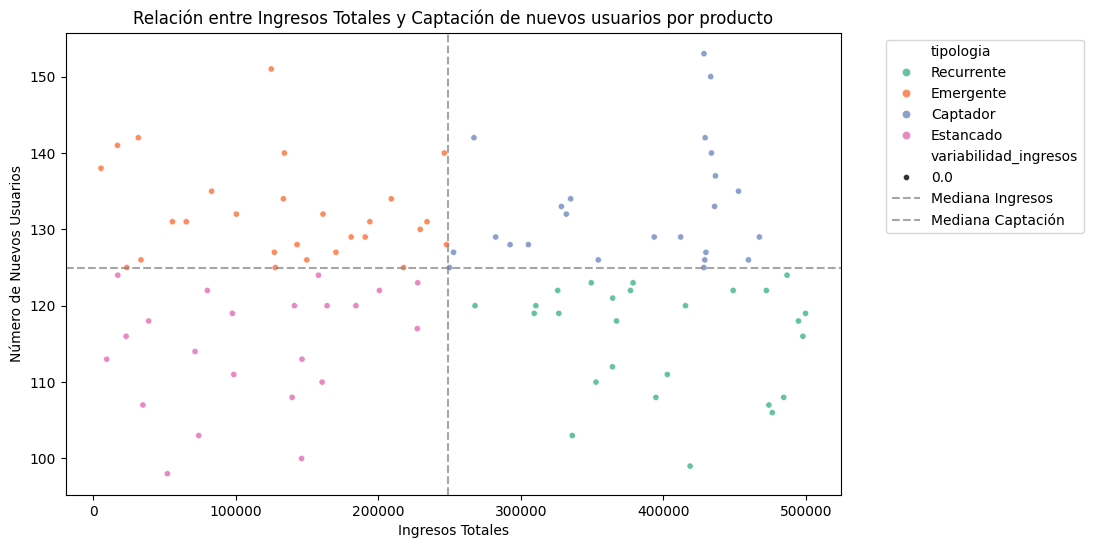

In [90]:
plt.figure(figsize=(10,6))
sns.scatterplot(#creación de la representación gráfica
    data=resumen_productos,
    x="ingresos_totales",
    y="num_usuarios_nuevos",
    hue="tipologia",#otorgará un color a cada categoría
    size="variabilidad_ingresos",#asigna tamaño de los puntos en base a la variabilidad de ingresos (mayor desviación standard mayor será el punto)
    sizes=(20,300),#rangos del size
    palette="Set2"
)
#dibujo de lineas de corte
plt.axvline(mediana_ingresos, color="gray", linestyle="--", alpha=0.7, label="Mediana Ingresos")#linea vertical
plt.axhline(mediana_captacion, color="gray", linestyle="--", alpha=0.7, label="Mediana Captación")#linea horizontal

#titulos y etiquetas
plt.title("Relación entre Ingresos Totales y Captación de nuevos usuarios por producto")
plt.xlabel("Ingresos Totales")
plt.ylabel("Número de Nuevos Usuarios")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # mueve la leyenda fuera del gráfico

plt.show()

La gráfica scatterplot divide los resultados en 4 cuadrantes, para mostrar la situación de los productos en venta.
Análisis por cuadrantes:
- **Cuadrante superior derecho** --> Productos estrella (captadores). Se sitúa a la derecha de la mediana (facturan más que la mediana), y por encima de la mediana (atrae más usuarios que la mediana).
Como estrategia de negocio, es importante protegerlos. Mantener la inversión en stock y campañas publicitarias, suponiendo el motor principal de ventas y atracción de usuarios nuevos.

- **Cuadrante inferior derecho** --> Son productos recurrentes, con grandes ingresos, pero baja captación de nuevos clientes. A pesar de ello, tiene una base de clientes fieles.
Como estrategia de negocio, es importante mantener estos clientes fieles como cartera, ya que suponen una buena parte de los ingresos de negocio. Si estos clientes fieles se marchan, dichos productos dejarán de generar ingresos, ya que no captan nuevos usuarios. Mantener contacto directo y constante para mantenerlos en cartera.

- **Cuadrante superior izquierdo** --> Productos emergentes, con bajos ingresos pero alta captación de clientes nuevos. Los clientes prueban el producto y la marca, pero no supone una gran fuente de ingresos.
Como estrategia de negocio, propongo potenciar este cuadrante, diseñando nuevas estrategias para ofrecer versiones superiores. El objetivo es que estos clientes pasen a consumir productos de mayor valor.

- **Cuadrante inferior izquierdo** --> Productos estancados, que tienen poca captación y suponen bajos ingresos.
Como estrategia de negocio es recomendable la optimización o eliminación del producto. Hay que evaluar el rediseño del producto, un descuento final para liquidarlos o descartarlos del catálogo.

Como conclusión final, es importante centrarse en los productos captadores y emergentes, ya que son los que más beneficio producen. Aún así, es importante crear una estrategia de captación y retención de clientes, de otra manera, a la larga, el negocio puede correr el riesgo de perder su posición en el mercado, en cuanto a la falta de innovación y la bajada de ventas y clientes fijos.



**Ejercicio 2** - Análisis geográfico y compañía - usuario y oportunidades de expansión

Analizar la relación entre el país de las compñías vendedoras, el país de residencia de los usuarios y el flujo de compra entre países.

El negocio está basado en mercados locales (mismo país usuario-compañía) o hay una oportunidad real de expansión internacional abriendo más compañçias en ciertos países?


Combinar las tablas necesarias

In [91]:
#vuelvo a mostrar las tablas que tiene la base de datos
from sqlalchemy import text#traductor/puente entre python y mysql
with engine.connect() as conn:
  result = conn.execute(text("SHOW TABLES;"))#ejecuto la consulta
  for row in result:
    print(row)

('companies',)
('credit_cards',)
('products',)
('transaction',)
('transaction_product',)
('users',)
('vistamarketing',)


Para este ejercicio será necesario juntar 3 tablas:

transaction --> df

users --> users_df

companies --> companies_df

In [92]:
#muestro la tabla df
df.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,distance_km,mes,hora,estado_transaccion,dia_semana,anyo,franja,product_ids_lista,fecha_primera_compra,es_nuevo_usuario
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,59.95,2024-08,7,Aceptada,Wednesday,2024,mañana,"[16, 26, 97, 87]",2015-02-06 02:39:31,False
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,1157.10,2020-07,15,Aceptada,Tuesday,2020,tarde,"[30, 11, 16, 81]",2015-08-03 18:53:18,False
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,540.32,2017-09,19,Aceptada,Monday,2017,noche,[72],2016-01-19 04:28:25,False
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,28.52,2017-01,18,Aceptada,Thursday,2017,noche,[18],2015-01-13 09:37:42,False
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,539.82,2023-09,4,Aceptada,Saturday,2023,madrugada,"[35, 33, 19]",2015-03-04 10:31:44,False


In [93]:
#importo tabla users
tabla = "users"
users_df=pd.read_sql(tabla, engine)
users_df.head()

,id,name,surname,phone,email,birth_date,country,city,postal_code,address,signup_date,user_segment,income_band,continent
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,2014-04-23,young_professional,high,America
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,"Aug 23, 1992",United States,Philadelphia,19101,903 Sit Ave,2014-07-04,young_professional,high,America
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,"Apr 29, 1998",United States,Houston,77001,736-2063 Tellus St.,2014-02-15,frequent_shopper,high,America
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,"Feb 18, 1989",United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,2014-08-21,premium,high,America
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,"Sep 26, 1998",United States,Philadelphia,19101,341-2821 Ultrices Av.,2013-04-28,frequent_shopper,high,America


In [94]:
#importo tabla companies
tabla = "companies"
companies_df = pd.read_sql(tabla, engine)
companies_df.head()


,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


In [95]:
#merge de tablas transaction, users y companies
df_geo = pd.merge(#merge con tabla users
    df,
    users_df[["id", "country"]],#importo solo las columnas id y country
    left_on="user_id",
    right_on="id",
    how="left"
).rename(columns={"country" : "country_user"})#renombro columna country a country_user
#merge con tabla companies
df_geo = pd.merge(
    df_geo,
    companies_df[["company_id","country"]],#importo las columnas company_id y country
    left_on="business_id",
    right_on="company_id",
    how="left"
).rename(columns={"country" : "country_company"})#renombro la columna country a country_company

df_geo[["user_id","country_user","business_id","country_company"]].head()

,user_id,country_user,business_id,country_company
0,4713,France,b-2458,Netherlands
1,2118,United States,b-2390,Ireland
2,2115,Canada,b-2230,United States
3,3025,Netherlands,b-2266,Sweden
4,215,Canada,b-2598,Belgium


Crea una variable clave de análisis: compra_local = True/False

In [96]:
df_geo["compra_local"] = df_geo["country_user"] == df_geo["country_company"]
df_geo[["user_id","country_user","business_id","country_company","compra_local"]].head()

,user_id,country_user,business_id,country_company,compra_local
0,4713,France,b-2458,Netherlands,False
1,2118,United States,b-2390,Ireland,False
2,2115,Canada,b-2230,United States,False
3,3025,Netherlands,b-2266,Sweden,False
4,215,Canada,b-2598,Belgium,False


Analiza el comportamiento global:

- Porcentaje de transacciones locales vs. internacionales

- Porcentaje de facturación local vs. internacional

In [97]:
#transacciones
porcentaje_transacciones = df_geo["compra_local"].value_counts(normalize=True) * 100#cálculo de valores locales vs, internacionales. Value_counts cuenta cuantos true/false hay. normalize=true convierte los conteos en proporciones de 0 a 1 y al multiplicar por 100 los transforma en porcentaje
print(porcentaje_transacciones.rename({True : "Local", False : "Internacional"}).round(2))#imprimo el resultado, y renombro true a local y false a internacional, redondeo a 2 dígitos el porcentaje

compra_local
Internacional    88.14
Local            11.86
Name: proportion, dtype: float64


In [98]:
#facturacion
porcentaje_facturacion = (df_geo.groupby("compra_local")["amount"].sum() / df_geo["amount"].sum()) * 100#agrupo según si la compra es local o internacional, hago el sumatorio de los amounts, y lo divido por el sumatorio totla de amounts multiplicado por 100 para obtener el porcentaje
print(porcentaje_facturacion.rename({True : "Local", False : "Internacional"}).round(2))#imprimo el resultado, renombro true a local y false a internacional, redondeo a 2 dígitos el porcentaje

compra_local
Internacional    88.13
Local            11.87
Name: amount, dtype: float64


In [99]:
(df_geo.columns)

Index(['id_x', 'card_id', 'business_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount',
       'tax_amount', 'shipping_amount', 'channel', 'campaign_id',
       'device_type', 'is_international', 'decline_reason', 'distance_km',
       'mes', 'hora', 'estado_transaccion', 'dia_semana', 'anyo', 'franja',
       'product_ids_lista', 'fecha_primera_compra', 'es_nuevo_usuario', 'id_y',
       'country_user', 'company_id', 'country_company', 'compra_local'],
      dtype='str')

tanto en el porcentaje de facturación como de transacciones, podemos ver que un 88% provienen de transacciones internaciones, mientras que las locales suponen solo un 11,8%. Las transacciones internacionales tiene un gran peso en la empresa.

Análisis por país de usuario, por cada país de usuario:

- % de compras a compañías del mismo país
- % de compras a compañías internacionales
- Importe total de compra

In [100]:
pais_usuario = df_geo.groupby("country_user").agg(#agrupo por country_user y uso método agregado
    importe_total = ("amount","sum"),#hago el sumatorio total de amount
    compras_locales = ("compra_local", lambda x: (x == True).mean() * 100),#uso una funcion lambda para calcular la media de compras locales
    compras_internaciones = ("compra_local", lambda x: (x == False).mean() * 100)#uso una funcion lambda para calcular la media de compras internacionales
).reset_index().round(2)#lo convierto a dataframe y redondeo a 2 dígitos
pais_usuario

,country_user,importe_total,compras_locales,compras_internaciones
0,Canada,2688940.83,9.71,90.29
1,France,2488997.24,6.28,93.72
2,Germany,2573251.67,16.94,83.06
3,Italy,2603393.17,17.10,82.90
4,Netherlands,2675165.65,19.32,80.68
5,Poland,2512973.74,0.00,100.00
6,Portugal,2638023.31,0.00,100.00
7,Spain,2693566.24,1.74,98.26
8,Sweden,2490810.72,21.30,78.70
9,United Kingdom,2838889.37,17.29,82.71


Estos datos reflejan que los usuarios de todos los países compran mayoritariamente en negocios internacionales. Suecia es el país con más compras locales, suponiendo un 21,30% del total de compras, y un 78,70% para las internacionales. Seguida por Holanda, con un 19,32% de ventas locales, frente al 80,68% de ventas internacionales.

En contrasposición, vemos que Polonia y Portugal no hacen compras locales, el 100% proviene de compras internacionales.

Análisis por país de compañía, por cada país de compañía, calcula qué parte de su facturación proviene de:

- Usuarios locales
- Usuarios internacionales

In [101]:
pais_companyia = df_geo.groupby("country_company").agg(#agrupo por country_company y uso un método agregado
    ventas_totales = ("amount","sum"),#sumatorio del amount por país
    ventas_locales = ("compra_local", lambda x: (x == True).mean() * 100),#uso de nuevo la función lambda para calcular la media de ventas locales
    ventas_internacionales = ("compra_local", lambda x: (x == False).mean() * 100)#uso de nuevo la función lambda para calcular la media de ventas internacionales
).reset_index().round(2)#lo convierto a dataframe y redondeo a 2 dígitos
pais_companyia

,country_company,ventas_totales,ventas_locales,ventas_internacionales
0,Australia,699013.06,0.00,100.00
1,Belgium,952208.75,0.00,100.00
2,Canada,558568.76,46.04,53.96
3,China,239034.47,0.00,100.00
4,France,1416084.26,11.36,88.64
5,Germany,4020364.07,11.12,88.88
6,Ireland,715220.46,0.00,100.00
7,Italy,4087557.38,10.72,89.28
8,Netherlands,4506571.38,11.50,88.50
9,New Zealand,705159.09,0.00,100.00


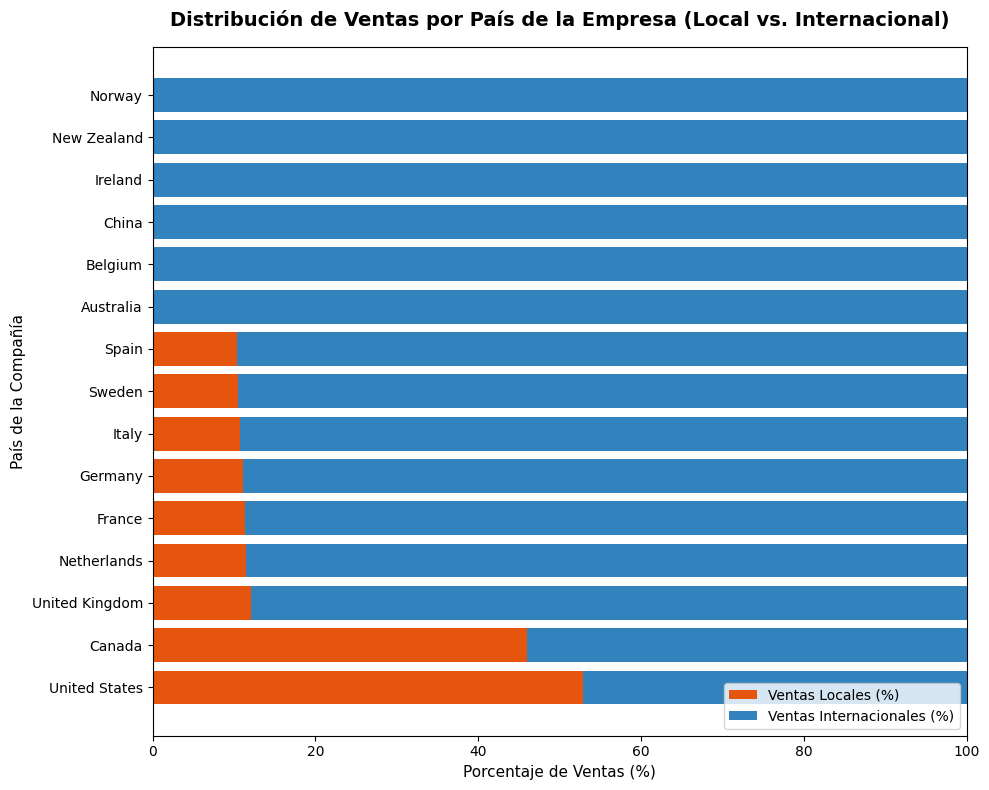

In [102]:
#saco el gráfico de ventas
plt.figure(figsize=(10,8))
#uso plt.barh en lugar de barplot para poder apilar las barras, y ver de manera gráfica las ventas locales vs. internacionales
pais_companyia_ordenado = pais_companyia.sort_values(by='ventas_internacionales', ascending=True)#ordeno los países por ventas internacionales
plt.barh(pais_companyia_ordenado["country_company"], pais_companyia_ordenado["ventas_locales"], color='#e6550d', label='Ventas Locales (%)')
plt.barh(pais_companyia_ordenado["country_company"], pais_companyia_ordenado["ventas_internacionales"], left=pais_companyia_ordenado["ventas_locales"], color='#3182bd', label='Ventas Internacionales (%)')#uso el left para poder apilar las barras

plt.title('Distribución de Ventas por País de la Empresa (Local vs. Internacional)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de Ventas (%)', fontsize=11)
plt.ylabel('País de la Compañía', fontsize=11)
plt.xlim(0, 100)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

En esta gráfica de barras apiladas, se distinguen claramente dos grupos. 6 países dependen totalmente de ventas internacionales (el 100%), no tienen ninguna venta local.

Otros 7 países se encuentran por debajo del 13% de ventas locales. En contraposición, Canadá y Estados Unidos tienen unos datos bastante más igualados, el porcentaje de ventas locales e internacionales es bastante igualado hacia el 50%. Concretamente, las ventas locales en Canadá suponen el 46,04%, y en Estados Unidos el 52,80%.

**¿En qué países valdría la pena abrir más negocios locales?**
En los 6 países que lideran la lista, y todas sus compras son internacionales (Noruega, Nueva Zelanda, Irlanda, China, Bélgica y Australia). Existe una demanda que las compañías locales no son capaced de atraer, ya que, como vimos, ningún usuarios de ningún país tiene 0 compras (locales o internacionales). Por lo que sería conveniente analizar el mercado, qué productos se compran más o despiertna más interés, y ver qué negocios locales los suministran y/o producirlos localmente con los datos extraídos.

**¿Hay países con demanda pero con poca oferta local?**
Los países que lideran el gráfico (Noruega, Nueva Zelanda, Irlanda, China, Bélgica y Australia), todos tienen compras y el 100% son internacionales. Hay demanda, pero no hay oferta.

**¿El negocio depende demasiado de compañías de un país?**
Conectando con el análisis de pareto mencionado anteriormente, vemos que más del 70% de ventas se desarrollan en 7 países (España, Suecia, Italia, Alemania, Francia, Holanda, Inglaterra), pero cuyas ventas locales se sitúan entre un 10 y un 12% de las ventas locales. Dependen de vender a otros países, no de un mercado local fuerte.

**¿Abrir compañías locales reduciría fricción o aumentaría conversión?**
Es probable que en los 6 países con un 0% de ventas locales reduzca fricción o aumente conversión. Factores como envíos internacionales, tipos de cambio, aduanas o incluso, regulaciones, suelen generar fricción en compras internacionales. Tener presencia local reduciría dicha fricción capturando la demanda a través de negocios locales.

**Nivel 3** - Visualización ejecutiva y storytelling

Ejercicio 1 - Mini-dashboard interdepartamental

Construye un mini-dashboard en Python usando Google Colab.


Creación de una figura única con 4 subplots orientado a ventas/comercial

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20940\4125105142.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_paises, x='importe_total', y='country_user', ax=axes[0, 1], palette='Blues_r')#orden de eiquetas, países en vertical para que sea un gráfico de barras horizontal


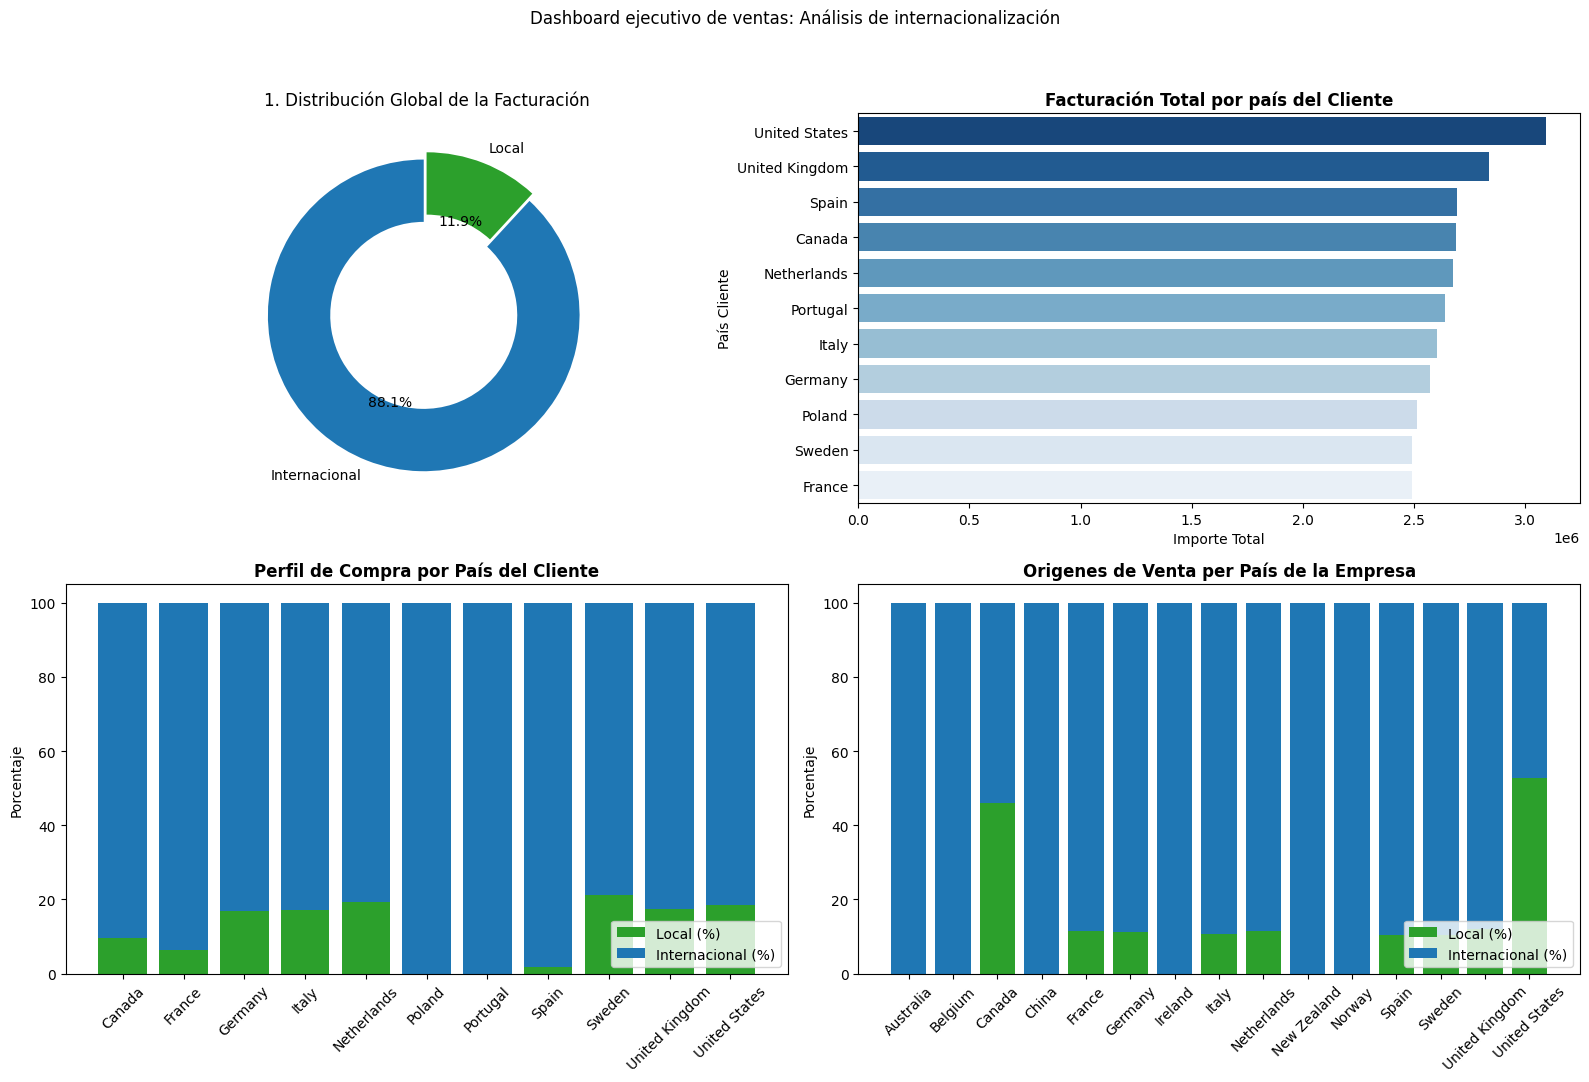

In [103]:
fig, axes = plt.subplots(2,2, figsize=(16,11))#crea el grafico dividido en 4 ventanas (2x2)
fig.suptitle("Dashboard ejecutivo de ventas: Análisis de internacionalización")
#facturación global
porc_fact = (df_geo.groupby("compra_local")["amount"].sum() / df_geo["amount"].sum() * 100)#agrupopor compra local y sumo el amount por true / false. lo divido entre el sumatorio total de amount y multiplico * 100 para sacar el porcentaje
axes[0,0].pie(porc_fact,labels=["Internacional","Local"], autopct='%1.1f%%', startangle=90, #axes[0,0] es la posición (1a ventana), pie es la forma gráfica y muestro con 1 decimal
               colors=['#1f77b4', '#2ca02c'], explode=(0.05, 0), wedgeprops=dict(width=0.4))#explode separa la pieza local
axes[0, 0].set_title('1. Distribución Global de la Facturación')
#ranking de la facturación por país del usuario
top_paises = pais_usuario.sort_values(by='importe_total', ascending=False)#ordeno paises de mayor a menor orden volumen de dinero
sns.barplot(data=top_paises, x='importe_total', y='country_user', ax=axes[0, 1], palette='Blues_r')#orden de eiquetas, países en vertical para que sea un gráfico de barras horizontal
axes[0, 1].set_title('Facturación Total por país del Cliente', fontsize=12, fontweight='bold')#etiquetas en la 2a ventana (arriba a la derecha)
axes[0, 1].set_xlabel('Importe Total')
axes[0, 1].set_ylabel('País Cliente')
#habitos de compra por pais de cliente
axes[1, 0].bar(pais_usuario['country_user'], pais_usuario['compras_locales'], label='Local (%)', color='#2ca02c')#compras locales en verde
axes[1, 0].bar(pais_usuario['country_user'], pais_usuario['compras_internaciones'], bottom=pais_usuario['compras_locales'], label='Internacional (%)', color='#1f77b4')#compras internacionales en azul con bottom(empieza a dibujar la linea donde acaba la verde para rellenar)
axes[1, 0].set_title('Perfil de Compra por País del Cliente', fontsize=12, fontweight='bold')#etiquetas
axes[1, 0].set_ylabel('Porcentaje')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(loc='lower right')
#origen de las ventas por pais de la empresa
axes[1, 1].bar(pais_companyia['country_company'], pais_companyia['ventas_locales'], label='Local (%)', color='#2ca02c')#ventas por paises
axes[1, 1].bar(pais_companyia['country_company'], pais_companyia['ventas_internacionales'], bottom=pais_companyia['ventas_locales'], label='Internacional (%)', color='#1f77b4')
axes[1, 1].set_title('Origenes de Venta per País de la Empresa', fontsize=12, fontweight='bold')#etiquetas
axes[1, 1].set_ylabel('Porcentaje')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Ejercicio 2** - Informe Ejecutivo

**Análisis Personal**

Este análisis examina los datos de ventas de una empresa para comprender los patrones de compra de sus clientes y la ubicación de las empresas proveedoras. Se ha evaluado la proporción de ventas locales (transacciones dentro del mismo país) y ventas internacionales. También se ha analizado la facturación total por país de los clientes, sus hábitos de compra y el origen de las ventas de las empresas por país.

El primer gráfico revela una clara desproporción: el 88,1% de las transacciones corresponden a ventas internacionales, frente a solo un 11,9% de ventas locales.

El segundo gráfico muestra el ranking de facturación por país. Estados Unidos lidera con 3,1 millones de €, seguido por el Reino Unido con 2,83 millones de €. En tercer lugar, España supera ligeramente a Canadá, con 2,69 millones de € frente a 2,68 millones de € respectivamente. Los países con menor facturación son Suecia y Francia, ambos con 2,48 millones de €.

Respecto a los hábitos de compra de los clientes, la mayoría de los países adquieren productos predominantemente de negocios internacionales, con porcentajes que oscilan entre el 80% y el 100%. Las compras a negocios nacionales son mínimas, sin superar el 20%. Destaca el caso de Polonia y Portugal, donde el 100% de sus compras se realizan a empresas internacionales.

Finalmente, analizando las ventas de las empresas por país, solo Estados Unidos y Canadá presentan un equilibrio entre ventas locales e internacionales. En Estados Unidos, las ventas locales representan el 52,80% y las internacionales el 47,20%, mientras que en Canadá estas cifras son 46,04% y 53,96% respectivamente. Adicionalmente, 7 países registran un bajo porcentaje de ventas locales (entre el 10% y el 12% del total), siendo el resto internacionales. Los 6 países restantes dependen exclusivamente de ventas internacionales, ya que no registran ventas locales.

En conclusión, se observa una marcada dependencia del comercio internacional en detrimento del mercado local. Esto podría deberse a que los comercios o negocios locales no ofrecen los productos o servicios que los clientes o empresas requieren. Sería crucial, especialmente en los países con 0% de compra/venta local, analizar el comportamiento y las necesidades de los clientes para fomentar la introducción de estos productos en el mercado local. Para los países con un porcentaje de ventas locales, se recomienda continuar apoyando esos productos y analizar el comportamiento para aumentar la oferta local.

Desde el punto de vista del negocio, es fundamental buscar un equilibrio del 50%-50% entre ventas locales e internacionales. Las razones son diversas; entre ellas, la dependencia exclusiva de productos extranjeros puede incrementar el precio final y expone a la empresa a regulaciones y situaciones financieras adversas (recesiones económicas, cierres de empresas, etc.). Por tanto, se aconseja encarecidamente analizar a los clientes para satisfacer sus necesidades, impulsar la economía local y diversificar la oferta.

**Análisis con IA**

1. Resumen general

Análisis descriptivo y geográfico de las transacciones globales de la compañía orientado al departamento de Ventas/Comercial. El objetivo principal es evaluar la distribución de la facturación entre mercados locales e internacionales para identificar patrones de consumo, cuellos de botella en la oferta regional y oportunidades de expansión comercial.

2. Hallazgos clave

Dominio del mercado cross-border: El 88,1% del volumen total de ventas proviene de transacciones internacionales, frente a un marginal 11,9% de volumen local.

Concentración de ingresos: EE. UU. lidera las ventas globales con 3,1 M€, seguido de Reino Unido (2,83 M€). España (2,69 M€) y Canadá (2,68 M€) mantienen un empate técnico en la tercera posición.

Dependencia exterior de la demanda: En todos los mercados, más del 80% del gasto se destina a empresas extranjeras. Destacan Polonia y Portugal, donde el 100% de la demanda es atendida por sellers internacionales.

Polarización de la oferta: Solo EE. UU. (52,8% local) y Canadá (46,0% local) presentan una base de empresas con penetración equilibrada en su propio mercado. 6 países dependen al 100% de la exportación al registrar un 0% de ventas domésticas.

3. Riesgos detectados

Vulnerabilidad operativa y de margen: La alta dependencia del producto extranjero expone a la compañía a fluctuaciones en tipos de cambio, aranceles, barreras regulatorias y costes logísticos elevados que encarecen el precio final.

Inexistencia de red comercial local: La ausencia total de ventas locales en mercados clave sugiere una falta de prospección y captación de comercios (sellers) regionales.

4. Oportunidades

Captación de demanda cautiva: Existe un gran volumen de compra consolidado en países como España, Portugal y Polonia que puede redirigirse hacia proveedores locales para incrementar el margen neto por transacción.

Diversificación de portfolio: Posibilidad de equilibrar el mix de ventas hacia una distribución objetivo 50% local - 50% internacional para asegurar la estabilidad financiera ante recesiones regionales.

5. Recomendaciones

Plan de Onboarding Comercial: Desplegar una estrategia de captación de comercios locales en los países con tasa de compra externa superior al 95% (Portugal, Polonia, España) para cubrir la demanda interna insatisfecha.

Incentivos a la Exportación Equilibrada: Mantener el soporte a los grandes exportadores (EE. UU. y Reino Unido) mientras se analizan los hábitos de consumo locales para escalar la presencia de productos regionales.